# OpenClaw Issue Corpus Analysis
## Research-Oriented Analysis of GitHub Issues from `openclaw/openclaw`

**Objective**: Analyze 22,613 GitHub issues to understand development trends, community concerns, and how the issue space relates to stability, plasticity, and generalization — for use in a research paper.

In [1]:
# ── Section 1: Environment Setup & Imports ──────────────────────────────
import json
import re
import os
import csv
import warnings
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

warnings.filterwarnings('ignore')

# Paths
BASE_DIR = Path("/Users/janus/Desktop/coding/crawler_github_issue")
FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

# Plot style: publication-friendly
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})
sns.set_style("whitegrid")
print("Environment ready.")
print(f"pandas={pd.__version__}, numpy={np.__version__}, matplotlib={matplotlib.__version__}")

Environment ready.
pandas=2.3.3, numpy=2.0.2, matplotlib=3.9.4


## Section 2: Data Loading & Initial Inspection

In [2]:
# ── Section 2: Load data from JSONL ──────────────────────────────────────
# JSONL is more reliable than CSV for this data (body field contains newlines, commas, quotes)
jsonl_path = BASE_DIR / "openclaw_issues.jsonl"

issues = []
with open(jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        issues.append(json.loads(line.strip()))

df = pd.DataFrame(issues)
print(f"Loaded {len(df)} issues")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst 3 rows (selected fields):")
df[['number', 'title', 'state', 'created_at', 'user_login']].head(3)

Loaded 22613 issues

Columns: ['number', 'title', 'body', 'labels', 'state', 'created_at', 'updated_at', 'closed_at', 'user_login', 'html_url', 'statement_text']

Data types:
number             int64
title             object
body              object
labels            object
state             object
created_at        object
updated_at        object
closed_at         object
user_login        object
html_url          object
statement_text    object
dtype: object

Missing values:
number               0
title                0
body                 0
labels               0
state                0
created_at           0
updated_at           0
closed_at         9251
user_login           0
html_url             0
statement_text       0
dtype: int64

First 3 rows (selected fields):


,number,title,state,created_at,user_login
0,2,Login fails with 'WebSocket Error (socket hang...,closed,2025-11-27T02:46:28Z,bheemreddy-samsara
1,3,"WA business, groups & office hours",closed,2025-11-27T12:50:37Z,codeagencybe
2,4,Images not passed to Claude CLI - only path re...,closed,2025-11-28T06:35:56Z,steipete


In [3]:
# ── Section 3: Data Cleaning & Preprocessing ────────────────────────────

# 3a. Parse timestamps
for col in ['created_at', 'updated_at', 'closed_at']:
    df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')

# 3b. Extract temporal features
df['year'] = df['created_at'].dt.year
df['month'] = df['created_at'].dt.to_period('M')
df['quarter'] = df['created_at'].dt.to_period('Q')
df['year_month'] = df['created_at'].dt.strftime('%Y-%m')

# 3c. Issue lifecycle: days from creation to close
df['lifetime_days'] = (df['closed_at'] - df['created_at']).dt.total_seconds() / 86400

# 3d. Check for empty title+body garbage
empty_both = df[(df['title'].str.strip() == '') & (df['body'].str.strip() == '')]
print(f"Issues with both empty title AND body: {len(empty_both)}")

# 3e. Check for exact duplicates (same number)
dup_numbers = df['number'].duplicated().sum()
print(f"Duplicate issue numbers: {dup_numbers}")

# 3f. Create cleaned text field
df['cleaned_text'] = df['title'].fillna('') + '\n\n' + df['body'].fillna('')

# 3g. Text length features
df['title_len'] = df['title'].str.len()
df['body_len'] = df['body'].str.len()

# 3h. Parse labels (stored as list in JSONL, confirm type)
print(f"\nLabels field type sample: {type(df['labels'].iloc[0])}")
# Labels are already lists from JSON parsing
df['label_count'] = df['labels'].apply(lambda x: len(x) if isinstance(x, list) else 0)

# 3i. Check date range
print(f"\nDate range: {df['created_at'].min()} to {df['created_at'].max()}")
print(f"States: {df['state'].value_counts().to_dict()}")
print(f"Avg title length: {df['title_len'].mean():.1f} chars")
print(f"Avg body length: {df['body_len'].mean():.1f} chars")
print(f"Body is empty: {(df['body'].str.strip() == '').sum()} issues ({(df['body'].str.strip() == '').mean()*100:.1f}%)")
print(f"\nCleaning complete. {len(df)} issues retained (no garbage removal needed).")

Issues with both empty title AND body: 0
Duplicate issue numbers: 0

Labels field type sample: <class 'list'>

Date range: 2025-11-27 02:46:28+00:00 to 2026-03-25 07:26:47+00:00
States: {'closed': 13362, 'open': 9251}
Avg title length: 74.0 chars
Avg body length: 2184.2 chars
Body is empty: 97 issues (0.4%)

Cleaning complete. 22613 issues retained (no garbage removal needed).


## Section 4-5: Corpus Overview & Descriptive Statistics

In [4]:
# ── Section 5: Basic Corpus Overview Statistics ─────────────────────────
print("="*60)
print("CORPUS OVERVIEW")
print("="*60)
print(f"Total issues:        {len(df):,}")
print(f"Open issues:         {(df['state']=='open').sum():,} ({(df['state']=='open').mean()*100:.1f}%)")
print(f"Closed issues:       {(df['state']=='closed').sum():,} ({(df['state']=='closed').mean()*100:.1f}%)")
print(f"Date range:          {df['created_at'].min().strftime('%Y-%m-%d')} to {df['created_at'].max().strftime('%Y-%m-%d')}")
print(f"Span:                ~{(df['created_at'].max() - df['created_at'].min()).days} days")
print(f"Unique contributors: {df['user_login'].nunique():,}")
print(f"")
print(f"Title length:  mean={df['title_len'].mean():.0f}, median={df['title_len'].median():.0f}, max={df['title_len'].max()}")
print(f"Body length:   mean={df['body_len'].mean():.0f}, median={df['body_len'].median():.0f}, max={df['body_len'].max()}")
print(f"Empty body:    {(df['body'].str.strip() == '').sum()} ({(df['body'].str.strip() == '').mean()*100:.1f}%)")
print(f"Issues w/ labels:  {(df['label_count'] > 0).sum()} ({(df['label_count'] > 0).mean()*100:.1f}%)")
print(f"")

# Top contributors
print("Top 15 issue creators:")
top_users = df['user_login'].value_counts().head(15)
for user, count in top_users.items():
    print(f"  {user:30s} {count:5d} ({count/len(df)*100:.1f}%)")

# Closed issue lifecycle
closed = df[df['state'] == 'closed']
print(f"\nClosed issue lifecycle (days):")
print(f"  Mean:   {closed['lifetime_days'].mean():.1f}")
print(f"  Median: {closed['lifetime_days'].median():.1f}")
print(f"  Max:    {closed['lifetime_days'].max():.1f}")

CORPUS OVERVIEW
Total issues:        22,613
Open issues:         9,251 (40.9%)
Closed issues:       13,362 (59.1%)
Date range:          2025-11-27 to 2026-03-25
Span:                ~118 days
Unique contributors: 14,058

Title length:  mean=74, median=74, max=958
Body length:   mean=2184, median=1721, max=65219
Empty body:    97 (0.4%)
Issues w/ labels:  12740 (56.3%)

Top 15 issue creators:
  coygeek                          146 (0.6%)
  fr33d3m0n                         68 (0.3%)
  johnlanni                         44 (0.2%)
  LeoFanKm                          38 (0.2%)
  ymxkj2006                         37 (0.2%)
  mcaxtr                            36 (0.2%)
  HenryLoenwind                     34 (0.2%)
  carrotRakko                       34 (0.2%)
  Lukavyi                           33 (0.1%)
  bmendonca3                        30 (0.1%)
  Stache73                          30 (0.1%)
  jinduwang1001-max                 30 (0.1%)
  henrybottter                      29 (0.1%)
  fwend

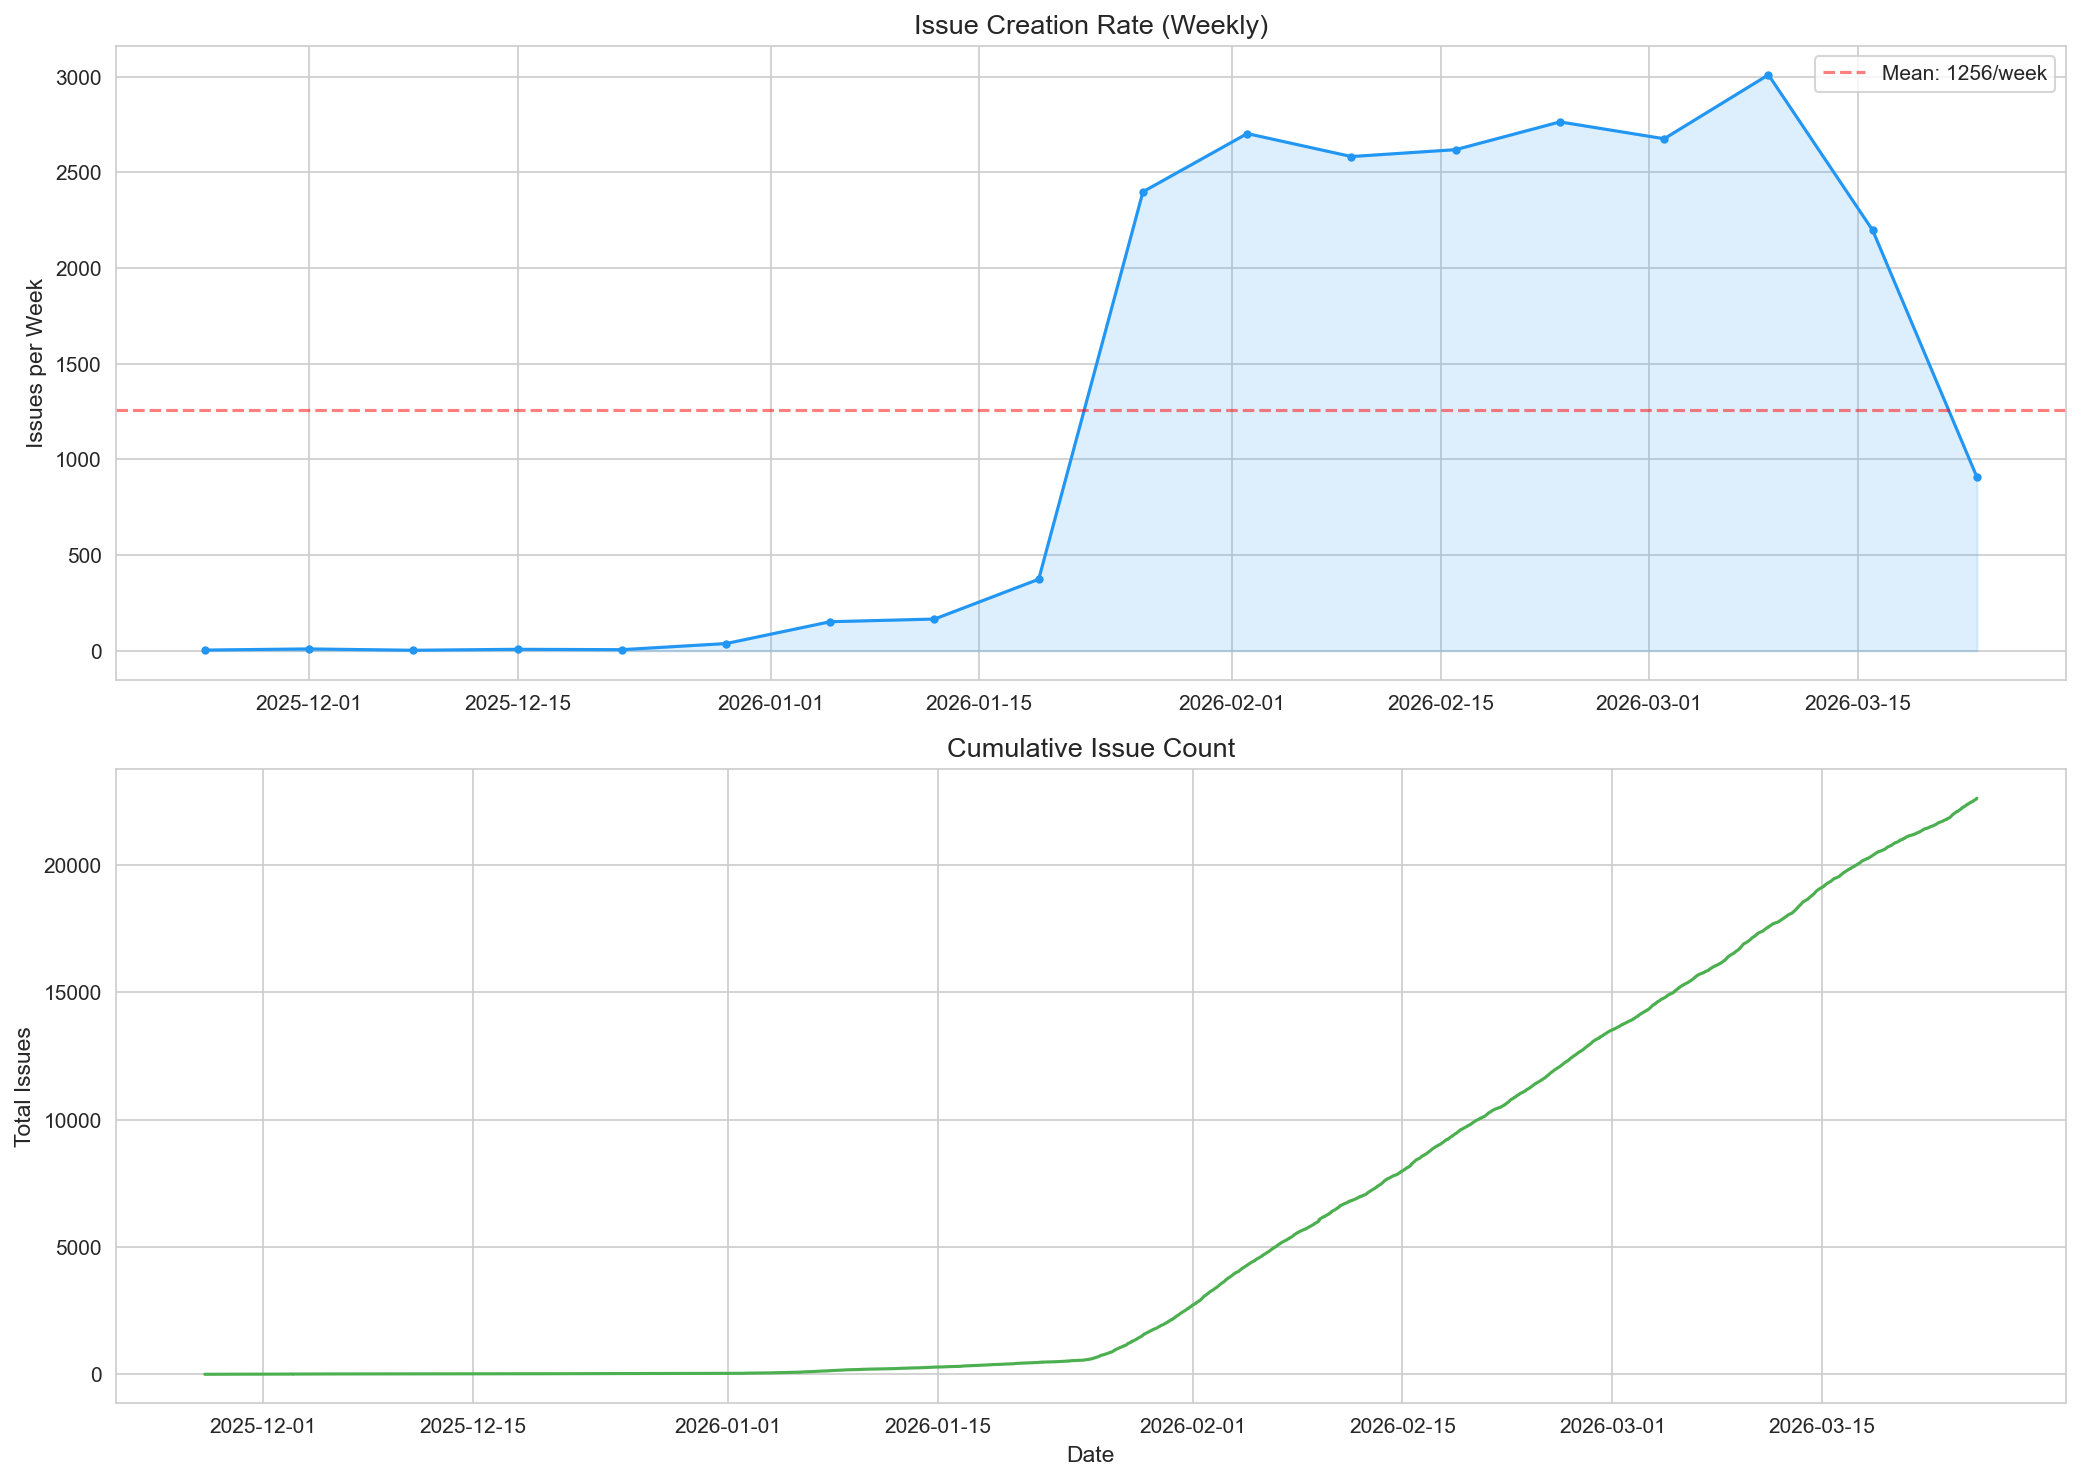

Saved to figures/temporal_trend.png


In [5]:
# ── Section 6: Temporal Trends ───────────────────────────────────────────

# 6a. Weekly issue creation trend
df['week'] = df['created_at'].dt.to_period('W')
weekly = df.groupby('week').size()
weekly.index = weekly.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Weekly creation rate
axes[0].plot(weekly.index, weekly.values, color='#2196F3', linewidth=1.5, marker='o', markersize=3)
axes[0].fill_between(weekly.index, weekly.values, alpha=0.15, color='#2196F3')
axes[0].set_title('Issue Creation Rate (Weekly)')
axes[0].set_ylabel('Issues per Week')
axes[0].axhline(weekly.mean(), color='red', linestyle='--', alpha=0.5, label=f'Mean: {weekly.mean():.0f}/week')
axes[0].legend()

# Cumulative issue count
cumulative = df.sort_values('created_at')['created_at'].reset_index(drop=True)
axes[1].plot(cumulative.values, range(1, len(cumulative)+1), color='#4CAF50', linewidth=1.5)
axes[1].set_title('Cumulative Issue Count')
axes[1].set_ylabel('Total Issues')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig(FIG_DIR / 'temporal_trend.png')
plt.show()
print(f"Saved to figures/temporal_trend.png")

Total unique labels: 47
Issues with at least one label: 12740 (56.3%)

Top 30 labels:
  bug                                       7776 (34.4%)
  stale                                     3766 (16.7%)
  enhancement                               2845 (12.6%)
  regression                                1230 (5.4%)
  bug:behavior                               854 (3.8%)
  security                                   206 (0.9%)
  r: support                                 184 (0.8%)
  bug:crash                                  129 (0.6%)
  invalid                                     70 (0.3%)
  r: moltbook                                 65 (0.3%)
  dedupe:child                                53 (0.2%)
  question                                    50 (0.2%)
  tui                                         49 (0.2%)
  close:duplicate                             49 (0.2%)
  dedupe:parent                               46 (0.2%)
  maintainer                                  36 (0.2%)
  r: spam      

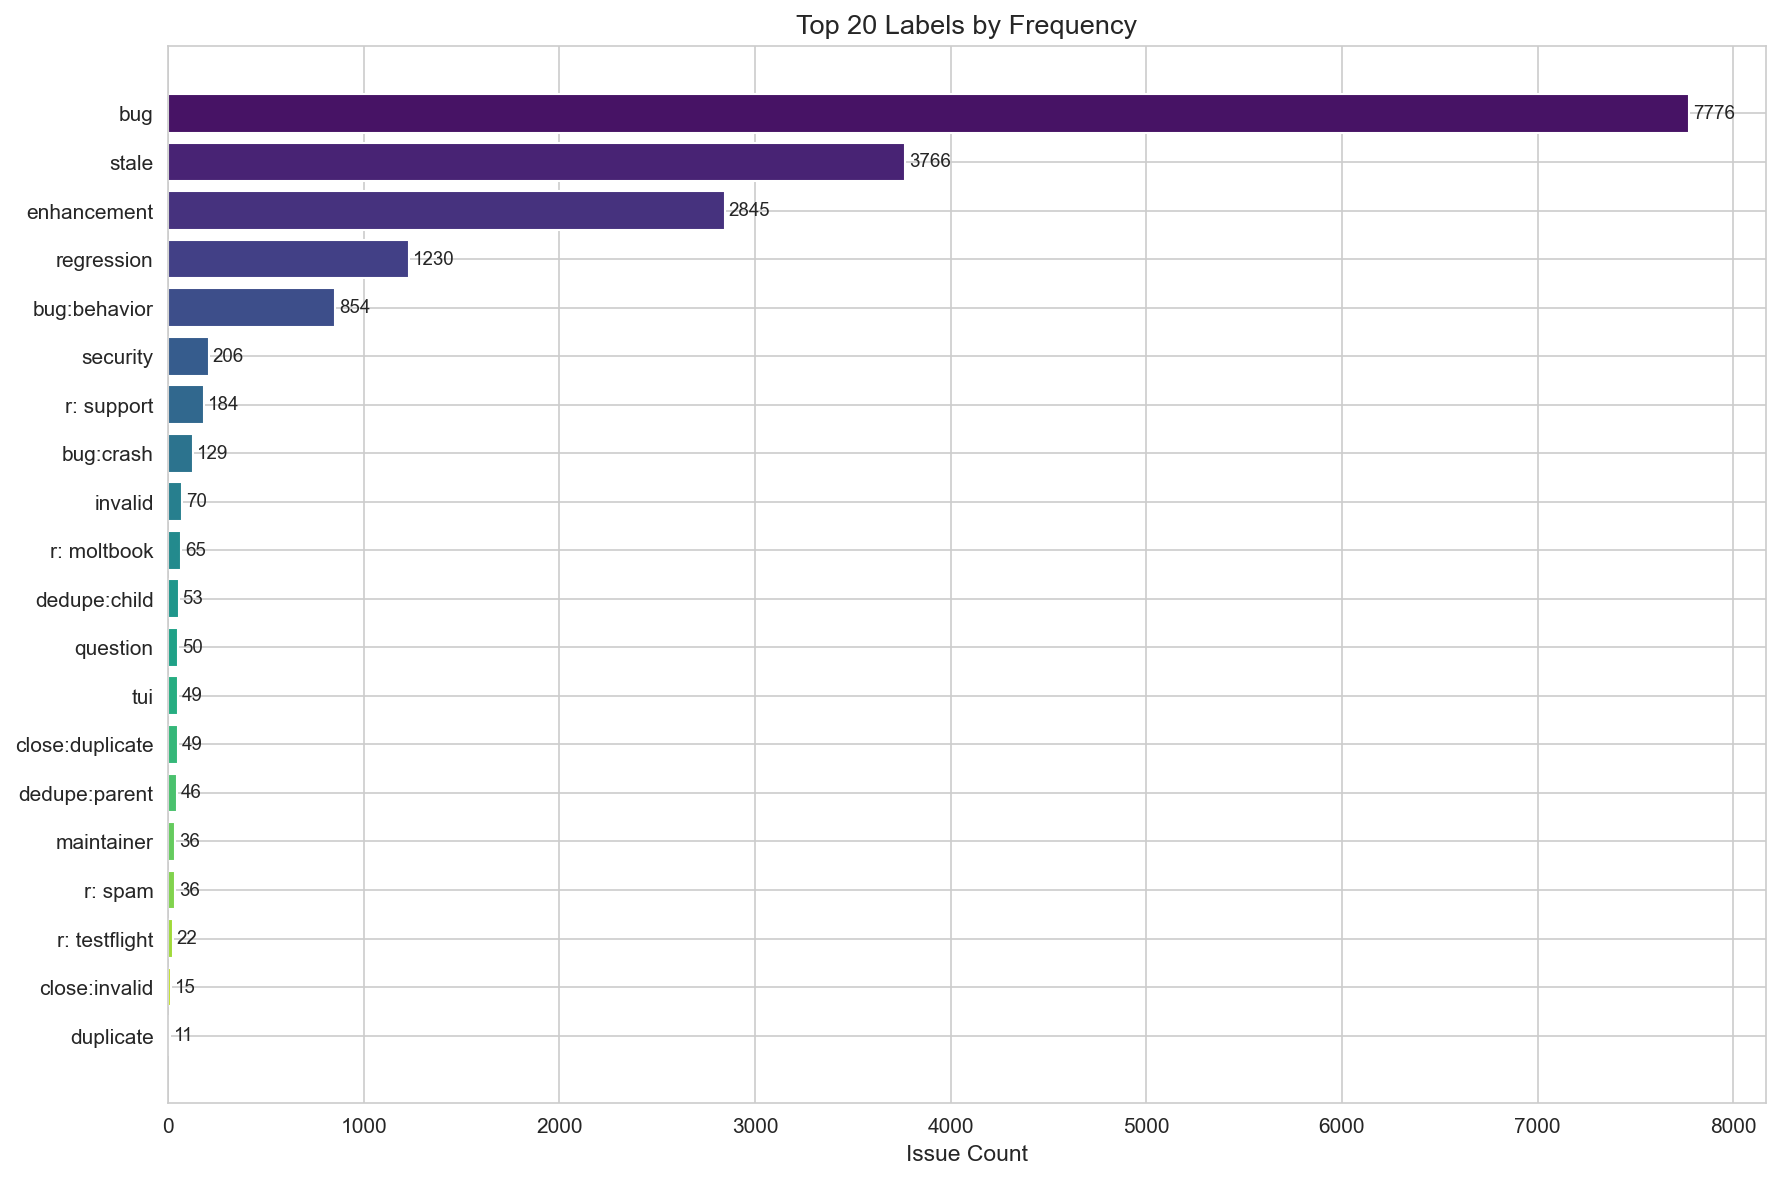

In [6]:
# ── Section 7: Label Frequency Analysis ──────────────────────────────────

# Flatten all labels
all_labels = []
for labels in df['labels']:
    if isinstance(labels, list):
        all_labels.extend(labels)

label_counts = Counter(all_labels)
print(f"Total unique labels: {len(label_counts)}")
print(f"Issues with at least one label: {(df['label_count'] > 0).sum()} ({(df['label_count'] > 0).mean()*100:.1f}%)\n")

# Top 30 labels
top30_labels = label_counts.most_common(30)
print("Top 30 labels:")
for label, count in top30_labels:
    print(f"  {label:40s} {count:5d} ({count/len(df)*100:.1f}%)")

# Plot top 20
top20 = label_counts.most_common(20)
fig, ax = plt.subplots(figsize=(12, 8))
labels_list = [x[0] for x in top20]
counts_list = [x[1] for x in top20]
bars = ax.barh(range(len(labels_list)), counts_list, color=sns.color_palette("viridis", len(labels_list)))
ax.set_yticks(range(len(labels_list)))
ax.set_yticklabels(labels_list)
ax.invert_yaxis()
ax.set_xlabel('Issue Count')
ax.set_title('Top 20 Labels by Frequency')
for i, (count, label) in enumerate(zip(counts_list, labels_list)):
    ax.text(count + 20, i, f'{count}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'label_frequency.png')
plt.show()

In [7]:
# ── Section 8: Keyword & Bigram Extraction via TF-IDF ────────────────────

# Prepare text — use cleaned_text, lowercased
texts = df['cleaned_text'].fillna('').str.lower()

# TF-IDF unigrams
tfidf_uni = TfidfVectorizer(max_features=200, stop_words='english', 
                             min_df=20, max_df=0.5, token_pattern=r'(?u)\b[a-zA-Z]{3,}\b')
X_uni = tfidf_uni.fit_transform(texts)
uni_scores = np.asarray(X_uni.mean(axis=0)).flatten()
uni_words = tfidf_uni.get_feature_names_out()
top_uni = sorted(zip(uni_words, uni_scores), key=lambda x: -x[1])[:50]

print("Top 50 TF-IDF Unigrams:")
for word, score in top_uni:
    print(f"  {word:25s} {score:.4f}")

# TF-IDF bigrams
tfidf_bi = TfidfVectorizer(max_features=200, stop_words='english',
                            ngram_range=(2, 2), min_df=10, max_df=0.3,
                            token_pattern=r'(?u)\b[a-zA-Z]{3,}\b')
X_bi = tfidf_bi.fit_transform(texts)
bi_scores = np.asarray(X_bi.mean(axis=0)).flatten()
bi_words = tfidf_bi.get_feature_names_out()
top_bi = sorted(zip(bi_words, bi_scores), key=lambda x: -x[1])[:40]

print("\nTop 40 TF-IDF Bigrams:")
for phrase, score in top_bi:
    print(f"  {phrase:35s} {score:.4f}")

Top 50 TF-IDF Unigrams:
  agent                     0.0710
  gateway                   0.0698
  session                   0.0572
  model                     0.0554
  message                   0.0536
  telegram                  0.0495
  error                     0.0431
  tool                      0.0431
  user                      0.0411
  api                       0.0397
  channel                   0.0377
  config                    0.0377
  messages                  0.0368
  cron                      0.0361
  context                   0.0350
  provider                  0.0350
  agents                    0.0338
  json                      0.0322
  file                      0.0310
  discord                   0.0298
  node                      0.0297
  memory                    0.0292
  install                   0.0279
  text                      0.0278
  https                     0.0276
  run                       0.0274
  token                     0.0271
  bot                       0.0

## Section 9-11: Theme Discovery & Classification

**Decision**: Skip the generic `bug` label in thematic analysis — it covers 34% of all issues but carries no topical information. Instead, rely on:
- Specific sub-labels (`bug:behavior`, `bug:crash`, `regression`)
- Text content (keywords & bigrams from TF-IDF)
- Label co-occurrences with `bug` (which reveal what *kind* of bug)

The theme taxonomy is constructed bottom-up from keyword patterns matched against `cleaned_text`.

In [9]:
# ── Section 9: Theme Taxonomy Definition ─────────────────────────────────
# Built from keyword extraction, label analysis, and issue sampling.
# The generic "bug" label is excluded from label-based signals — it's too broad.
# We use text-content patterns to discover what people actually care about.

THEME_RULES = {
    "Gateway / Connectivity": {
        "keywords": [
            r'\bgateway\b', r'\brestart\b', r'\bconnect', r'\bdisconnect',
            r'\bwebsocket\b', r'\bsocket\b', r'\btimeout\b', r'\bnetwork\b',
            r'\boffline\b', r'\bonline\b', r'\bheartbeat\b', r'\bping\b',
        ],
        "labels": ['gateway'],
    },
    "Memory / Context / Persistence": {
        "keywords": [
            r'\bmemory\b', r'\bcontext\b', r'\bpersist', r'\bforget',
            r'\bremember\b', r'\bhistory\b', r'\blong.?term\b', r'\bstate\b',
            r'\bretain', r'\bconversation.?history\b', r'\bcontext.?window\b',
            r'\bknowledge.?base\b', r'\bvector\b', r'\bembedding',
            r'\brag\b', r'\bretrieval\b',
        ],
        "labels": ['extensions: memory-core'],
    },
    "Channel Integration (Telegram/Discord/WhatsApp)": {
        "keywords": [
            r'\btelegram\b', r'\bdiscord\b', r'\bwhatsapp\b', r'\bslack\b',
            r'\bchannel\b', r'\bbot\b', r'\bwebhook\b', r'\bmessaging\b',
            r'\bsms\b', r'\bvoice\b', r'\bchat.?platform\b',
        ],
        "labels": ['channel: discord', 'channel: telegram'],
    },
    "Model / Provider / API": {
        "keywords": [
            r'\bmodel\b', r'\bprovider\b', r'\bapi.?key\b', r'\bopenai\b',
            r'\banthropic\b', r'\bclaude\b', r'\bgpt\b', r'\bollama\b',
            r'\bgemini\b', r'\bgroq\b', r'\btoken.?limit\b', r'\brate.?limit\b',
            r'\bllm\b', r'\bcompletion\b', r'\bstreaming\b',
        ],
        "labels": [],
    },
    "Tool Use / Browser / Environment": {
        "keywords": [
            r'\btool\b', r'\btools\b', r'\btool.?call', r'\bbrowser\b',
            r'\bscrape\b', r'\bscraping\b', r'\bselenium\b', r'\bplaywright\b',
            r'\bshell\b', r'\bcommand\b', r'\bexecut', r'\bfunction.?call',
            r'\bplugin\b', r'\bextension\b', r'\bmcp\b',
        ],
        "labels": [],
    },
    "Session / Multi-turn / Conversation": {
        "keywords": [
            r'\bsession\b', r'\bsessions\b', r'\bmulti.?turn\b',
            r'\bconversation\b', r'\bchat\b', r'\bthread\b', r'\bmessage\b',
            r'\bmessages\b', r'\breply\b', r'\brespons',
        ],
        "labels": [],
    },
    "Scheduling / Cron / Automation": {
        "keywords": [
            r'\bcron\b', r'\bschedul', r'\bautomat', r'\btrigger\b',
            r'\bperiodic\b', r'\binterval\b', r'\btimer\b', r'\bworkflow\b',
            r'\bjob\b', r'\bjobs\b', r'\btask\b',
        ],
        "labels": [],
    },
    "Installation / Setup / Config": {
        "keywords": [
            r'\binstall\b', r'\bsetup\b', r'\bconfig\b', r'\bconfigur',
            r'\bdocker\b', r'\benvironment\b', r'\bdeploy\b', r'\bnpm\b',
            r'\bpip\b', r'\byarn\b', r'\bbuild\b', r'\bpackage\b',
            r'\bdependenc', r'\bversion\b', r'\bupgrade\b', r'\bupdat',
        ],
        "labels": [],
    },
    "Error Handling / Crash / Reliability": {
        "keywords": [
            r'\berror\b', r'\bcrash', r'\bfail', r'\bexception\b',
            r'\bstack.?trace\b', r'\btraceback\b', r'\bunhandled\b',
            r'\brecov', r'\bretry\b', r'\brestart\b', r'\bunexpect',
            r'\bhang\b', r'\bfreeze\b', r'\bstuck\b', r'\bbrok',
        ],
        "labels": ['bug:crash', 'bug:behavior'],
    },
    "Agent Behavior / Reasoning / Planning": {
        "keywords": [
            r'\bagent\b', r'\bagents\b', r'\breason', r'\bplanning\b',
            r'\bplan\b', r'\bstep\b', r'\bsteps\b', r'\bthink',
            r'\bdecision\b', r'\bautonomous', r'\borchestrat',
            r'\bdelegate\b', r'\bsub.?agent\b', r'\bmulti.?agent\b',
        ],
        "labels": [],
    },
    "Security / Auth / Permissions": {
        "keywords": [
            r'\bsecur', r'\bauth', r'\bpermission\b', r'\baccess.?control',
            r'\btoken\b', r'\bcredential', r'\bencrypt', r'\bpassword\b',
            r'\bvulnerab', r'\binjection\b', r'\bsandbox\b',
        ],
        "labels": ['security'],
    },
    "UI / UX / Frontend": {
        "keywords": [
            r'\btui\b', r'\bui\b', r'\bux\b', r'\bfrontend\b',
            r'\bweb.?ui\b', r'\bdashboard\b', r'\binterface\b',
            r'\bdisplay\b', r'\brendering\b', r'\bbutton\b', r'\bformat',
            r'\bmarkdown\b', r'\bcode.?block\b',
        ],
        "labels": ['tui', 'app: web-ui'],
    },
}

# NOTE: "bug" and "stale" are meta/process labels — excluded from thematic signals.
# "enhancement" is a type label, not a topic — also excluded from theme matching.
# "regression" is used later in S/P/G analysis as a stability proxy.

print(f"Defined {len(THEME_RULES)} themes.")
for name, rules in THEME_RULES.items():
    n_kw = len(rules['keywords'])
    n_lb = len(rules['labels'])
    print(f"  {name:45s}  {n_kw:2d} keywords, {n_lb} labels")

Defined 12 themes.
  Gateway / Connectivity                         12 keywords, 1 labels
  Memory / Context / Persistence                 16 keywords, 1 labels
  Channel Integration (Telegram/Discord/WhatsApp)  11 keywords, 2 labels
  Model / Provider / API                         15 keywords, 0 labels
  Tool Use / Browser / Environment               15 keywords, 0 labels
  Session / Multi-turn / Conversation            10 keywords, 0 labels
  Scheduling / Cron / Automation                 11 keywords, 0 labels
  Installation / Setup / Config                  16 keywords, 0 labels
  Error Handling / Crash / Reliability           15 keywords, 2 labels
  Agent Behavior / Reasoning / Planning          14 keywords, 0 labels
  Security / Auth / Permissions                  11 keywords, 1 labels
  UI / UX / Frontend                             13 keywords, 2 labels


=== THEME DISTRIBUTION ===
Total issues:              22,613
Issues with ≥1 theme:     22,213 (98.2%)
Issues with 0 themes:     400 (1.8%)
Mean themes per issue:    6.69
Max themes on one issue:  12

Theme                                               Count       %
-----------------------------------------------------------------
  Installation / Setup / Config                    19,666   87.0%
  Agent Behavior / Reasoning / Planning            17,495   77.4%
  Session / Multi-turn / Conversation              16,854   74.5%
  Error Handling / Crash / Reliability             14,262   63.1%
  Tool Use / Browser / Environment                 13,695   60.6%
  Gateway / Connectivity                           12,191   53.9%
  Memory / Context / Persistence                   11,966   52.9%
  Model / Provider / API                           11,041   48.8%
  Channel Integration (Telegram/Discord/WhatsApp)  10,673   47.2%
  Scheduling / Cron / Automation                    8,690   38.4%
  Securi

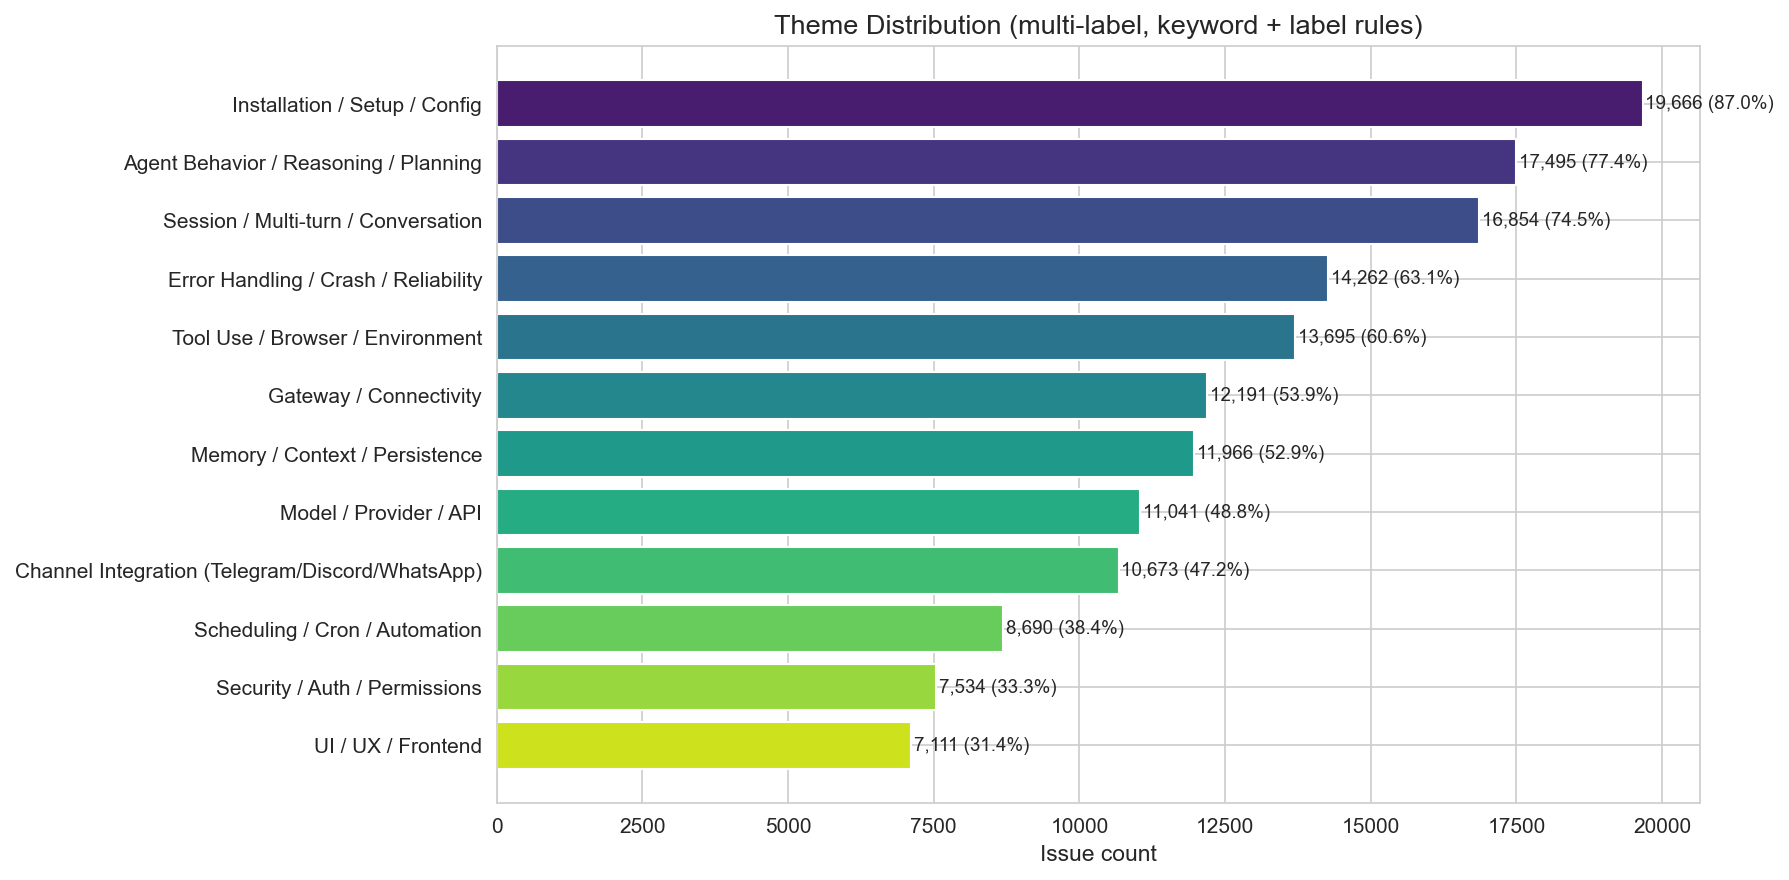

Saved figures/theme_distribution.png


In [10]:
# ── Section 10: Multi-label Theme Classification ─────────────────────────
import re
from collections import Counter

def classify_themes(row, rules):
    """Return list of matching theme names for a single issue."""
    text = str(row.get('cleaned_text', '')).lower()
    issue_labels = str(row.get('labels', '')).lower()
    matched = []
    for theme_name, rule in rules.items():
        # Check keywords in title+body text
        kw_hit = any(re.search(pat, text) for pat in rule['keywords'])
        # Check label overlap
        lb_hit = any(lb.lower() in issue_labels for lb in rule['labels']) if rule['labels'] else False
        if kw_hit or lb_hit:
            matched.append(theme_name)
    return matched

# Classify all issues
df['themes'] = df.apply(lambda r: classify_themes(r, THEME_RULES), axis=1)
df['n_themes'] = df['themes'].apply(len)

# ── Theme Distribution ───────────────────────────────────────────────────
theme_counter = Counter()
for themes in df['themes']:
    theme_counter.update(themes)

print("=== THEME DISTRIBUTION ===")
print(f"Total issues:              {len(df):,}")
print(f"Issues with ≥1 theme:     {(df['n_themes'] > 0).sum():,} ({(df['n_themes'] > 0).mean()*100:.1f}%)")
print(f"Issues with 0 themes:     {(df['n_themes'] == 0).sum():,} ({(df['n_themes'] == 0).mean()*100:.1f}%)")
print(f"Mean themes per issue:    {df['n_themes'].mean():.2f}")
print(f"Max themes on one issue:  {df['n_themes'].max()}")
print()

print(f"{'Theme':<50s} {'Count':>6s} {'%':>7s}")
print("-" * 65)
for theme, count in theme_counter.most_common():
    print(f"  {theme:<48s} {count:>6,d} {count/len(df)*100:>6.1f}%")

# ── Visualisation ────────────────────────────────────────────────────────
themes_sorted = theme_counter.most_common()
t_names = [t[0] for t in themes_sorted]
t_counts = [t[1] for t in themes_sorted]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(t_names)), t_counts, color=sns.color_palette("viridis", len(t_names)))
ax.set_yticks(range(len(t_names)))
ax.set_yticklabels(t_names, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Issue count")
ax.set_title("Theme Distribution (multi-label, keyword + label rules)")
for i, v in enumerate(t_counts):
    ax.text(v + 50, i, f"{v:,} ({v/len(df)*100:.1f}%)", va='center', fontsize=9)
plt.tight_layout()
plt.savefig("figures/theme_distribution.png", dpi=150)
plt.show()
print("Saved figures/theme_distribution.png")

=== REFINED THEME DISTRIBUTION (v2, scored) ===
Issues with ≥1 theme:     20,891 (92.4%)
Uncategorized:            1,722 (7.6%)
Mean themes per issue:    2.92

Theme                               Multi-label       %   Primary       %
---------------------------------------------------------------------------
  Gateway / Connectivity                 10,534   46.6%     4,761   21.1%
  Channel Integration                     8,222   36.4%     2,658   11.8%
  Model / LLM / Provider                  8,002   35.4%     3,403   15.0%
  Session Management                      7,562   33.4%       660    2.9%
  Installation / Deploy                   6,558   29.0%     3,463   15.3%
  Tool Use / Plugins                      5,264   23.3%       757    3.3%
  Crash / Error                           4,100   18.1%       800    3.5%
  Security / Auth                         4,058   17.9%       716    3.2%
  Memory / Context                        3,631   16.1%     1,033    4.6%
  Agent Orchestration   

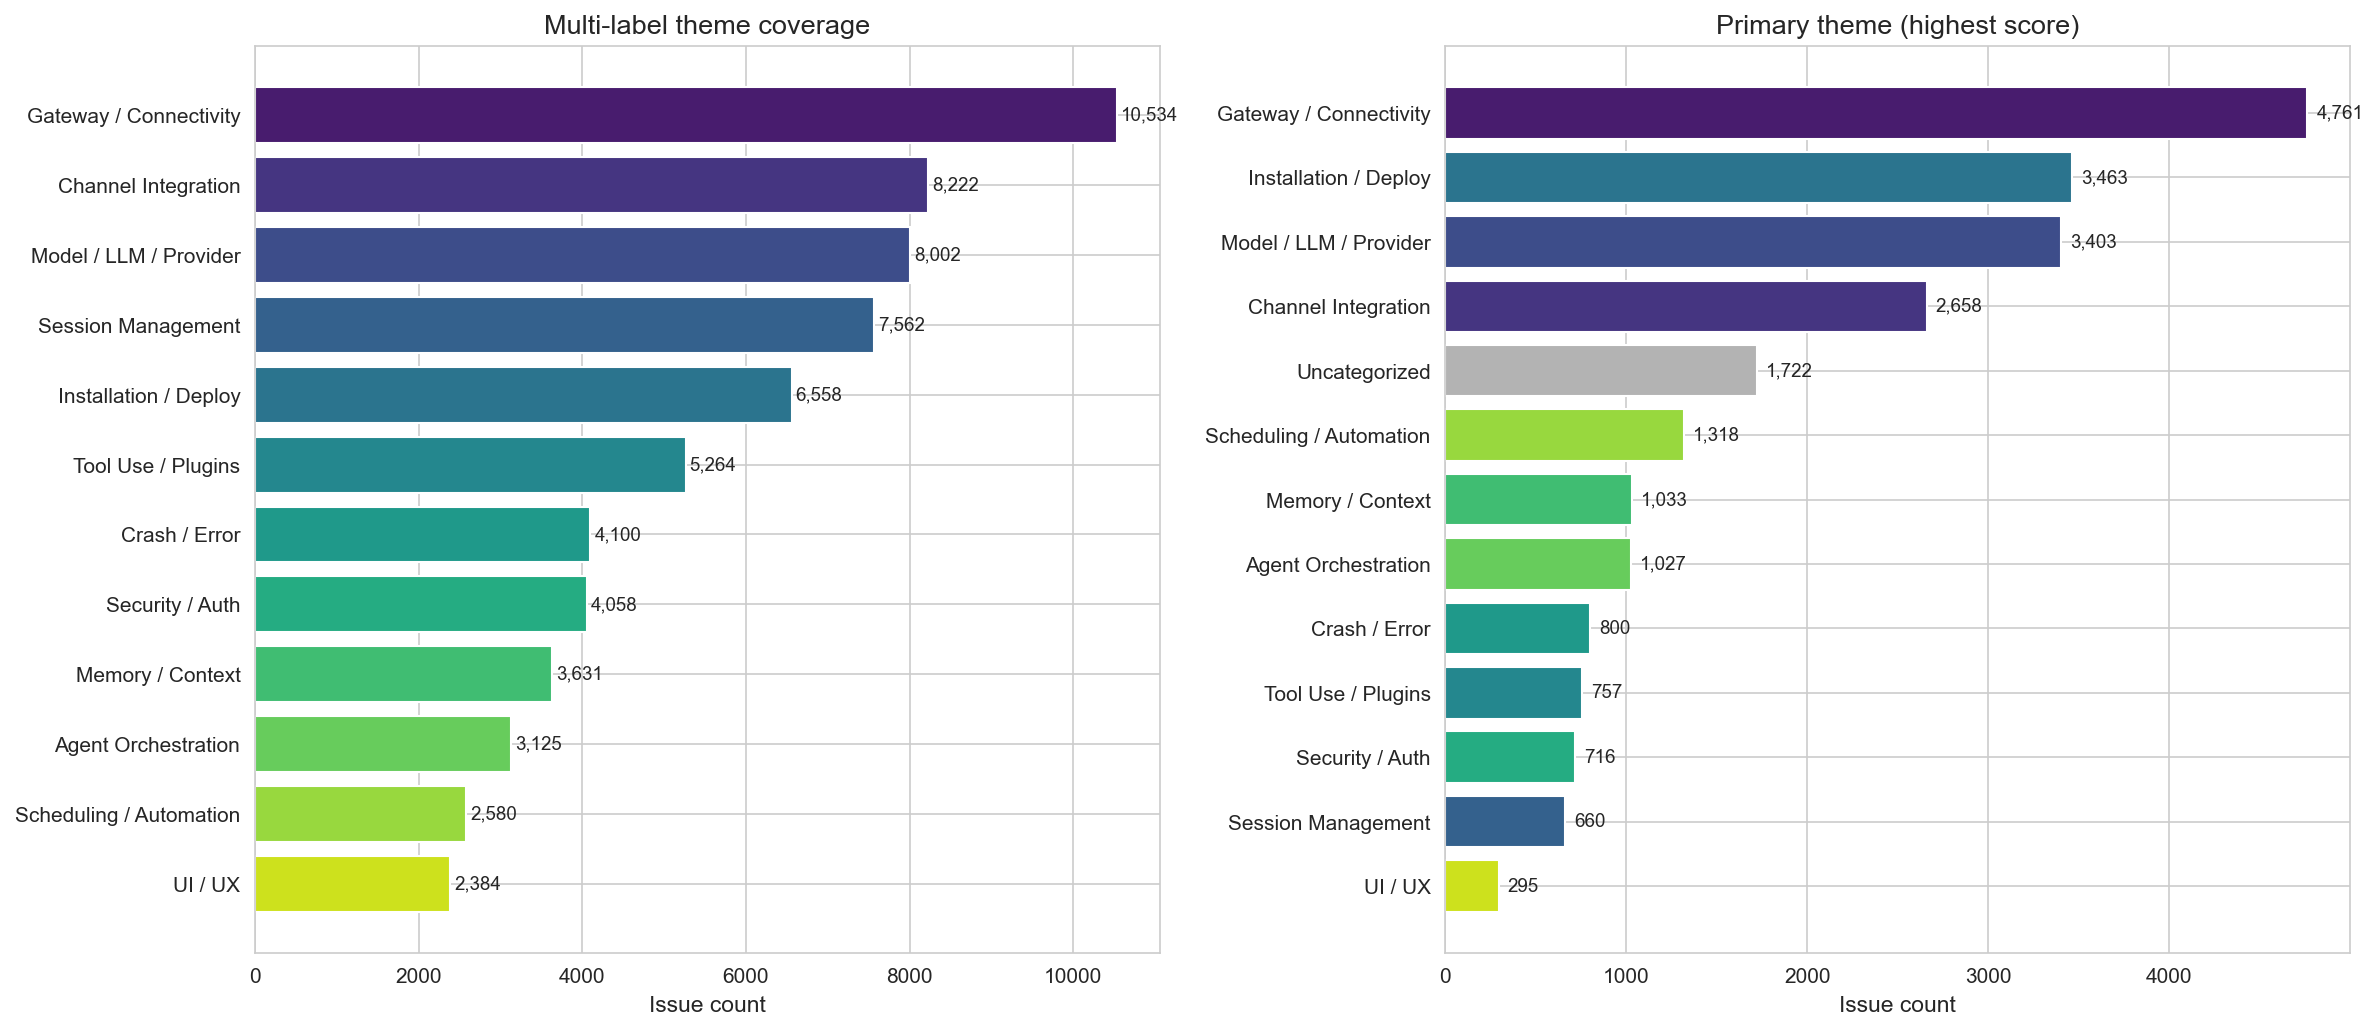

Saved figures/theme_distribution_v2.png


In [11]:
# ── Section 10b: Tighten Classification — Scored + Primary Theme ─────────
# The naive keyword presence gives 6.69 themes/issue (too broad).
# Strategy: (1) Score each theme by count of distinct keyword hits,
#           (2) Require ≥ MIN_HITS to count, (3) Assign primary = highest score.

import re
from collections import Counter

# Tighter, more discriminative keyword lists
THEME_RULES_V2 = {
    "Gateway / Connectivity": {
        "keywords": [
            r'\bopenclaw gateway\b', r'\bgateway\b', r'\bwebsocket\b',
            r'\bdisconnect', r'\breconnect', r'\bheartbeat\b',
            r'\bconnection.?lost\b', r'\bconnection.?error\b',
        ],
        "labels": ['gateway'],
        "min_hits": 1,
    },
    "Memory / Context": {
        "keywords": [
            r'\bmemory\b', r'\bcontext.?window\b', r'\bconversation.?history\b',
            r'\blong.?term.?memory\b', r'\bforgets?\b', r'\bremember\b',
            r'\bknowledge.?base\b', r'\bvector.?store\b', r'\bembedding',
            r'\brag\b', r'\bretrieval.?augment',
        ],
        "labels": ['extensions: memory-core'],
        "min_hits": 1,
    },
    "Channel Integration": {
        "keywords": [
            r'\btelegram\b', r'\bdiscord\b', r'\bwhatsapp\b', r'\bslack\b',
            r'\bwebhook\b', r'\bchannel.?integrat',
        ],
        "labels": ['channel: discord', 'channel: telegram'],
        "min_hits": 1,
    },
    "Model / LLM / Provider": {
        "keywords": [
            r'\bopenai\b', r'\banthropic\b', r'\bclaude\b', r'\bgpt.?[34]\b',
            r'\bollama\b', r'\bgemini\b', r'\bgroq\b', r'\bllm\b',
            r'\bmodel.?provider\b', r'\bapi.?key\b', r'\bstreaming\b',
            r'\btoken.?limit\b', r'\bcompletion\b',
        ],
        "labels": [],
        "min_hits": 1,
    },
    "Tool Use / Plugins": {
        "keywords": [
            r'\btool.?call', r'\bfunction.?call', r'\btool.?use\b',
            r'\btool.?execut', r'\bmcp\b', r'\bplugin\b',
            r'\bbrowser.?tool\b', r'\bweb.?search\b', r'\bscraping\b',
        ],
        "labels": [],
        "min_hits": 1,
    },
    "Session Management": {
        "keywords": [
            r'\bsession\b', r'\bsession.?id\b', r'\bmulti.?turn\b',
            r'\bsession.?timeout\b', r'\bsession.?state\b',
            r'\bsession.?manag',
        ],
        "labels": [],
        "min_hits": 1,
    },
    "Scheduling / Automation": {
        "keywords": [
            r'\bcron\b', r'\bschedul', r'\bperiodic\b', r'\binterval\b',
            r'\bautomat', r'\bworkflow\b', r'\btrigger\b',
        ],
        "labels": [],
        "min_hits": 2,  # "trigger" or "automat" alone too common
    },
    "Installation / Deploy": {
        "keywords": [
            r'\bdocker\b', r'\binstall', r'\bdeploy', r'\bnpm install\b',
            r'\bpip install\b', r'\bdocker.?compose\b', r'\bself.?host',
            r'\bset.?up\b', r'\bconfigur',
        ],
        "labels": [],
        "min_hits": 2,  # "install" or "configure" alone too common
    },
    "Crash / Error": {
        "keywords": [
            r'\bcrash', r'\bstack.?trace\b', r'\btraceback\b',
            r'\bunhandled.?exception\b', r'\bsegfault\b', r'\bpanic\b',
            r'\bfatal\b', r'\bcore.?dump\b', r'\berror.?handling\b',
            r'\bretry.?logic\b',
        ],
        "labels": ['bug:crash', 'bug:behavior', 'regression'],
        "min_hits": 1,
    },
    "Agent Orchestration": {
        "keywords": [
            r'\bagent\b', r'\bmulti.?agent\b', r'\bsub.?agent\b',
            r'\borchestrat', r'\bdelegate\b', r'\bplanning\b',
            r'\breason', r'\bautonomous', r'\bagent.?loop\b',
        ],
        "labels": [],
        "min_hits": 2,  # "agent" alone is too common
    },
    "Security / Auth": {
        "keywords": [
            r'\bsecur', r'\bauthenticat', r'\bauthoriz', r'\bpermission\b',
            r'\baccess.?control\b', r'\bencrypt', r'\bvulnerab',
            r'\bsandbox\b', r'\binjection\b',
        ],
        "labels": ['security'],
        "min_hits": 1,
    },
    "UI / UX": {
        "keywords": [
            r'\bweb.?ui\b', r'\bdashboard\b', r'\btui\b',
            r'\bfrontend\b', r'\bui.?bug\b', r'\brendering\b',
        ],
        "labels": ['tui', 'app: web-ui'],
        "min_hits": 1,
    },
}


def score_themes(row, rules):
    """Return dict {theme_name: score} for a single issue."""
    text = str(row.get('cleaned_text', '')).lower()
    issue_labels = str(row.get('labels', '')).lower()
    scores = {}
    for theme_name, rule in rules.items():
        score = sum(1 for pat in rule['keywords'] if re.search(pat, text))
        # Label hit counts as 2 points
        if rule['labels']:
            score += 2 * sum(1 for lb in rule['labels'] if lb.lower() in issue_labels)
        if score >= rule['min_hits']:
            scores[theme_name] = score
    return scores


# Apply scoring
df['theme_scores'] = df.apply(lambda r: score_themes(r, THEME_RULES_V2), axis=1)
df['themes_v2'] = df['theme_scores'].apply(lambda d: list(d.keys()))
df['n_themes_v2'] = df['themes_v2'].apply(len)
df['primary_theme'] = df['theme_scores'].apply(
    lambda d: max(d, key=d.get) if d else 'Uncategorized'
)

# ── Distribution ─────────────────────────────────────────────────────────
theme_counter2 = Counter()
for themes in df['themes_v2']:
    theme_counter2.update(themes)

primary_counts = df['primary_theme'].value_counts()

print("=== REFINED THEME DISTRIBUTION (v2, scored) ===")
print(f"Issues with ≥1 theme:     {(df['n_themes_v2'] > 0).sum():,} ({(df['n_themes_v2'] > 0).mean()*100:.1f}%)")
print(f"Uncategorized:            {(df['n_themes_v2'] == 0).sum():,} ({(df['n_themes_v2'] == 0).mean()*100:.1f}%)")
print(f"Mean themes per issue:    {df['n_themes_v2'].mean():.2f}")
print()

print(f"{'Theme':<35s} {'Multi-label':>11s} {'%':>7s}  {'Primary':>8s} {'%':>7s}")
print("-" * 75)
for theme, count in theme_counter2.most_common():
    pc = primary_counts.get(theme, 0)
    print(f"  {theme:<33s} {count:>11,d} {count/len(df)*100:>6.1f}%  {pc:>8,d} {pc/len(df)*100:>6.1f}%")
# Print Uncategorized
uc = primary_counts.get('Uncategorized', 0)
print(f"  {'Uncategorized':<33s} {'—':>11s} {'—':>7s}  {uc:>8,d} {uc/len(df)*100:>6.1f}%")

# ── Chart ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: multi-label
ts = theme_counter2.most_common()
names = [t[0] for t in ts]
counts = [t[1] for t in ts]
axes[0].barh(range(len(names)), counts, color=sns.color_palette("viridis", len(names)))
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names, fontsize=10)
axes[0].invert_yaxis()
axes[0].set_xlabel("Issue count")
axes[0].set_title("Multi-label theme coverage")
for i, v in enumerate(counts):
    axes[0].text(v + 50, i, f"{v:,}", va='center', fontsize=9)

# Right: primary theme
p_themes = primary_counts.index.tolist()
p_vals = primary_counts.values.tolist()
cmap = {t: c for t, c in zip(names, sns.color_palette("viridis", len(names)))}
cmap['Uncategorized'] = (0.7, 0.7, 0.7)
colors = [cmap.get(t, (0.5, 0.5, 0.5)) for t in p_themes]
axes[1].barh(range(len(p_themes)), p_vals, color=colors)
axes[1].set_yticks(range(len(p_themes)))
axes[1].set_yticklabels(p_themes, fontsize=10)
axes[1].invert_yaxis()
axes[1].set_xlabel("Issue count")
axes[1].set_title("Primary theme (highest score)")
for i, v in enumerate(p_vals):
    axes[1].text(v + 50, i, f"{v:,}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig("figures/theme_distribution_v2.png", dpi=150)
plt.show()
print("Saved figures/theme_distribution_v2.png")

## Section 12-13: Stability / Plasticity / Generalization (S/P/G)

**Framework** (from neural-network continual-learning theory, mapped to software systems):

| Dimension | Meaning in this context | Signal keywords |
|---|---|---|
| **Stability (S)** | System keeps working under change — bugs, regressions, crashes, breaking changes | regression, crash, broke, breaking, rollback, downgrade, was working |
| **Plasticity (P)** | Ability to learn/adapt — new features, extensibility, customization, model switching | feature request, enhancement, extensibility, plugin, customize, new provider |
| **Generalization (G)** | Works across diverse inputs/contexts — multi-channel, multi-model, edge cases, i18n | edge case, multi-channel, cross-platform, different models, unexpected input, i18n |

The generic `bug` label is **excluded** — it's too noisy (34% of issues). We rely on:
- Specific sub-labels: `regression`, `bug:crash`, `bug:behavior`, `enhancement`
- Text-content keyword patterns for each dimension

=== S/P/G CLASSIFICATION ===
Issues with ≥1 S/P/G dim: 19,236 (85.1%)
Unclassified:             3,377 (14.9%)

  Stability           multi-label: 13,257 (58.6%)  primary: 10,662 (47.1%)  mean score: 2.2
  Plasticity          multi-label: 13,160 (58.2%)  primary:  7,960 (35.2%)  mean score: 2.3
  Generalization      multi-label:  4,794 (21.2%)  primary:    614 (2.7%)  mean score: 1.3
  Unclassified                                     primary:  3,377 (14.9%)


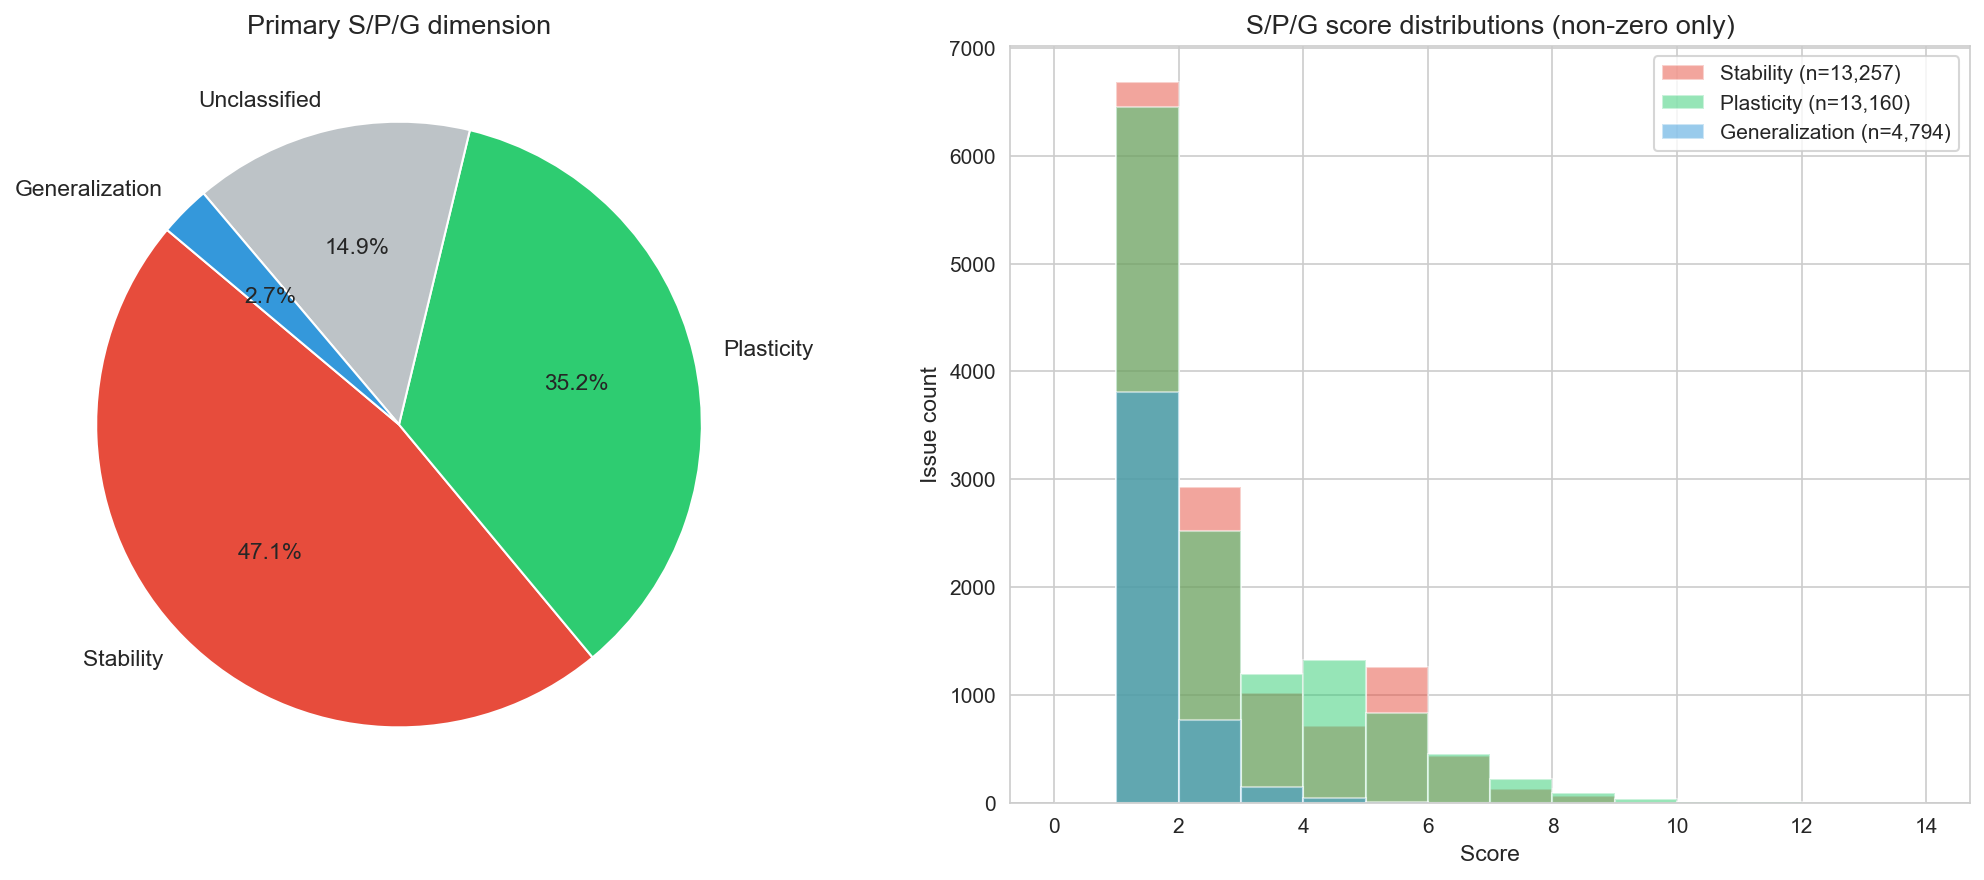

Saved figures/spg_classification.png


In [12]:
# ── Section 12: S/P/G Keyword Classifier ─────────────────────────────────
# Each issue gets a score for S, P, and G. Primary = highest.
# "bug" label excluded per user decision.

SPG_RULES = {
    "Stability": {
        "keywords": [
            r'\bregression\b', r'\bcrash', r'\bbroke\b', r'\bbroken\b',
            r'\bbreaking.?change', r'\brollback\b', r'\bdowngrade\b',
            r'\bwas.?working\b', r'\bused.?to.?work\b', r'\bno.?longer.?work',
            r'\bstop(ped)?.?working\b', r'\bfail(s|ed|ing)?\b',
            r'\bunstable\b', r'\bflaky\b', r'\bintermittent\b',
            r'\brace.?condition\b', r'\bdeadlock\b', r'\bcorrupt',
            r'\bdata.?loss\b', r'\binconsisten', r'\breliab',
            r'\bavailab', r'\buptime\b', r'\bdowntime\b',
        ],
        "labels": ['regression', 'bug:crash', 'bug:behavior'],
        "label_weight": 3,
    },
    "Plasticity": {
        "keywords": [
            r'\bfeature.?request\b', r'\benhancement\b', r'\bnew.?feature\b',
            r'\bextensib', r'\bcustomiz', r'\bplugin\b', r'\bextension\b',
            r'\bmodular', r'\bhook\b', r'\bhooks\b', r'\boverrid',
            r'\bswitch.?model\b', r'\bnew.?provider\b', r'\badapt',
            r'\brefactor\b', r'\bredesign\b', r'\bimprove\b',
            r'\bsupport.?for\b', r'\badd.?support\b', r'\bintegrat',
            r'\bproposed.?solution\b', r'\bwould.?be.?nice\b',
            r'\bwish\b', r'\bsuggest',
        ],
        "labels": ['enhancement'],
        "label_weight": 3,
    },
    "Generalization": {
        "keywords": [
            r'\bedge.?case\b', r'\bcorner.?case\b', r'\bunexpected.?input',
            r'\bmulti.?channel\b', r'\bcross.?platform\b', r'\bportab',
            r'\bdifferent.?model', r'\bmultiple.?provider', r'\bi18n\b',
            r'\blocali[zs]', r'\bunicode\b', r'\butf', r'\bnon.?english',
            r'\blarge.?scale\b', r'\bscalab', r'\bperformanc',
            r'\bconcurren', r'\bparallel\b', r'\bbatch\b',
            r'\bdiverse\b', r'\bvarious\b', r'\bgeneric\b',
            r'\bcompat', r'\binteroper', r'\bstandard',
        ],
        "labels": [],
        "label_weight": 0,
    },
}


def score_spg(row, rules):
    """Return dict {S/P/G: score} for a single issue."""
    text = str(row.get('cleaned_text', '')).lower()
    # Exclude generic "bug" label — use only specific sub-labels
    issue_labels = str(row.get('labels', '')).lower()
    scores = {}
    for dim, rule in rules.items():
        kw_score = sum(1 for pat in rule['keywords'] if re.search(pat, text))
        lb_score = rule['label_weight'] * sum(
            1 for lb in rule['labels'] if lb.lower() in issue_labels
        )
        total = kw_score + lb_score
        if total > 0:
            scores[dim] = total
    return scores


df['spg_scores'] = df.apply(lambda r: score_spg(r, SPG_RULES), axis=1)
df['spg_dims'] = df['spg_scores'].apply(lambda d: list(d.keys()))
df['n_spg'] = df['spg_dims'].apply(len)
df['primary_spg'] = df['spg_scores'].apply(
    lambda d: max(d, key=d.get) if d else 'Unclassified'
)

# Also store individual scores
df['s_score'] = df['spg_scores'].apply(lambda d: d.get('Stability', 0))
df['p_score'] = df['spg_scores'].apply(lambda d: d.get('Plasticity', 0))
df['g_score'] = df['spg_scores'].apply(lambda d: d.get('Generalization', 0))

# ── S/P/G Distribution ───────────────────────────────────────────────────
print("=== S/P/G CLASSIFICATION ===")
print(f"Issues with ≥1 S/P/G dim: {(df['n_spg'] > 0).sum():,} ({(df['n_spg'] > 0).mean()*100:.1f}%)")
print(f"Unclassified:             {(df['n_spg'] == 0).sum():,} ({(df['n_spg'] == 0).mean()*100:.1f}%)")
print()

for dim in ['Stability', 'Plasticity', 'Generalization']:
    count = (df['spg_scores'].apply(lambda d: dim in d)).sum()
    primary = (df['primary_spg'] == dim).sum()
    mean_s = df[df['spg_scores'].apply(lambda d: dim in d)][f'{dim[0].lower()}_score'].mean()
    print(f"  {dim:<18s}  multi-label: {count:>6,d} ({count/len(df)*100:.1f}%)  "
          f"primary: {primary:>6,d} ({primary/len(df)*100:.1f}%)  mean score: {mean_s:.1f}")

uc = (df['primary_spg'] == 'Unclassified').sum()
print(f"  {'Unclassified':<18s}  {'':>27s}  primary: {uc:>6,d} ({uc/len(df)*100:.1f}%)")

# ── Pie + Bar charts ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: primary S/P/G pie
spg_primary = df['primary_spg'].value_counts()
colors_spg = {'Stability': '#e74c3c', 'Plasticity': '#2ecc71',
              'Generalization': '#3498db', 'Unclassified': '#bdc3c7'}
pie_colors = [colors_spg.get(x, '#95a5a6') for x in spg_primary.index]
axes[0].pie(spg_primary.values, labels=spg_primary.index, colors=pie_colors,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11})
axes[0].set_title("Primary S/P/G dimension", fontsize=13)

# Right: score distributions
for dim, color in [('Stability', '#e74c3c'), ('Plasticity', '#2ecc71'),
                    ('Generalization', '#3498db')]:
    col = f'{dim[0].lower()}_score'
    vals = df[df[col] > 0][col]
    axes[1].hist(vals, bins=range(0, int(vals.max())+2), alpha=0.5,
                 label=f"{dim} (n={len(vals):,})", color=color, edgecolor='white')
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Issue count")
axes[1].set_title("S/P/G score distributions (non-zero only)")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/spg_classification.png", dpi=150)
plt.show()
print("Saved figures/spg_classification.png")

=== S/P/G × Theme (% of each theme's issues) ===
                Gateway / Connectivity  Channel Integration  Installation / Deploy  Crash / Error  Model / LLM / Provider  Session Management  Tool Use / Plugins  Memory / Context  Security / Auth  UI / UX  Scheduling / Automation  Agent Orchestration
Stability                         69.3                 60.8                   76.3           98.3                    64.8                63.1                65.5              60.0             66.2     59.5                     68.3                 63.2
Plasticity                        57.6                 62.0                   53.9           48.4                    62.1                62.1                81.2              71.1             66.1     51.9                     64.9                 67.1
Generalization                    22.9                 20.6                   25.2           23.7                    29.2                25.2                27.2              30.5             28.

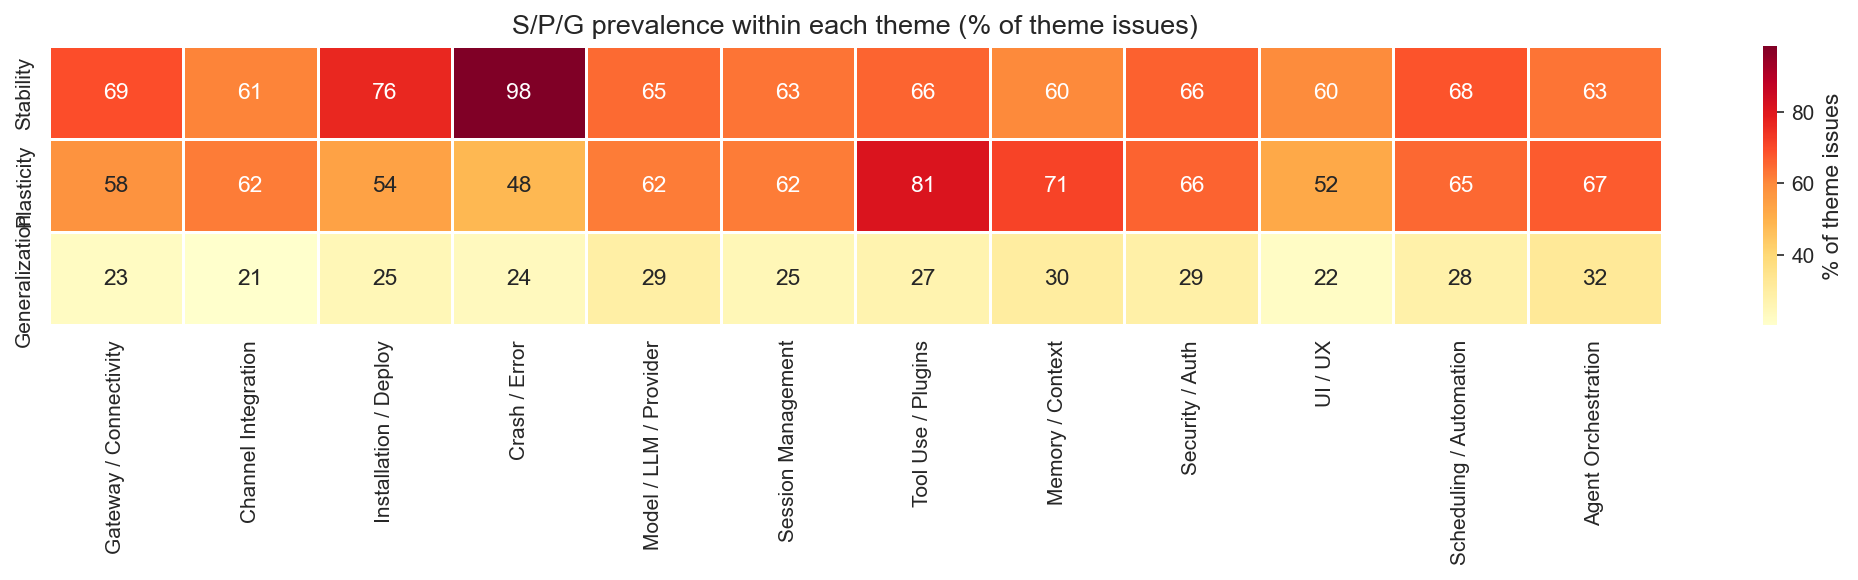

Saved figures/spg_theme_heatmap.png


In [13]:
# ── Section 13: S/P/G × Theme Cross-tabulation ──────────────────────────
# Which themes are associated with which S/P/G dimensions?

cross = []
for dim in ['Stability', 'Plasticity', 'Generalization']:
    dim_mask = df['spg_scores'].apply(lambda d: dim in d)
    row = {}
    for theme in theme_counter2.keys():
        theme_mask = df['themes_v2'].apply(lambda ts: theme in ts)
        both = (dim_mask & theme_mask).sum()
        row[theme] = both
    cross.append(row)

cross_df = pd.DataFrame(cross, index=['Stability', 'Plasticity', 'Generalization'])

# Normalize by theme total to get "% of theme's issues that are S/P/G"
theme_totals = pd.Series(theme_counter2)
cross_pct = cross_df.div(theme_totals, axis=1) * 100

print("=== S/P/G × Theme (% of each theme's issues) ===")
print(cross_pct.round(1).to_string())
print()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(cross_pct, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': '% of theme issues'})
ax.set_title("S/P/G prevalence within each theme (% of theme issues)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("figures/spg_theme_heatmap.png", dpi=150)
plt.show()
print("Saved figures/spg_theme_heatmap.png")

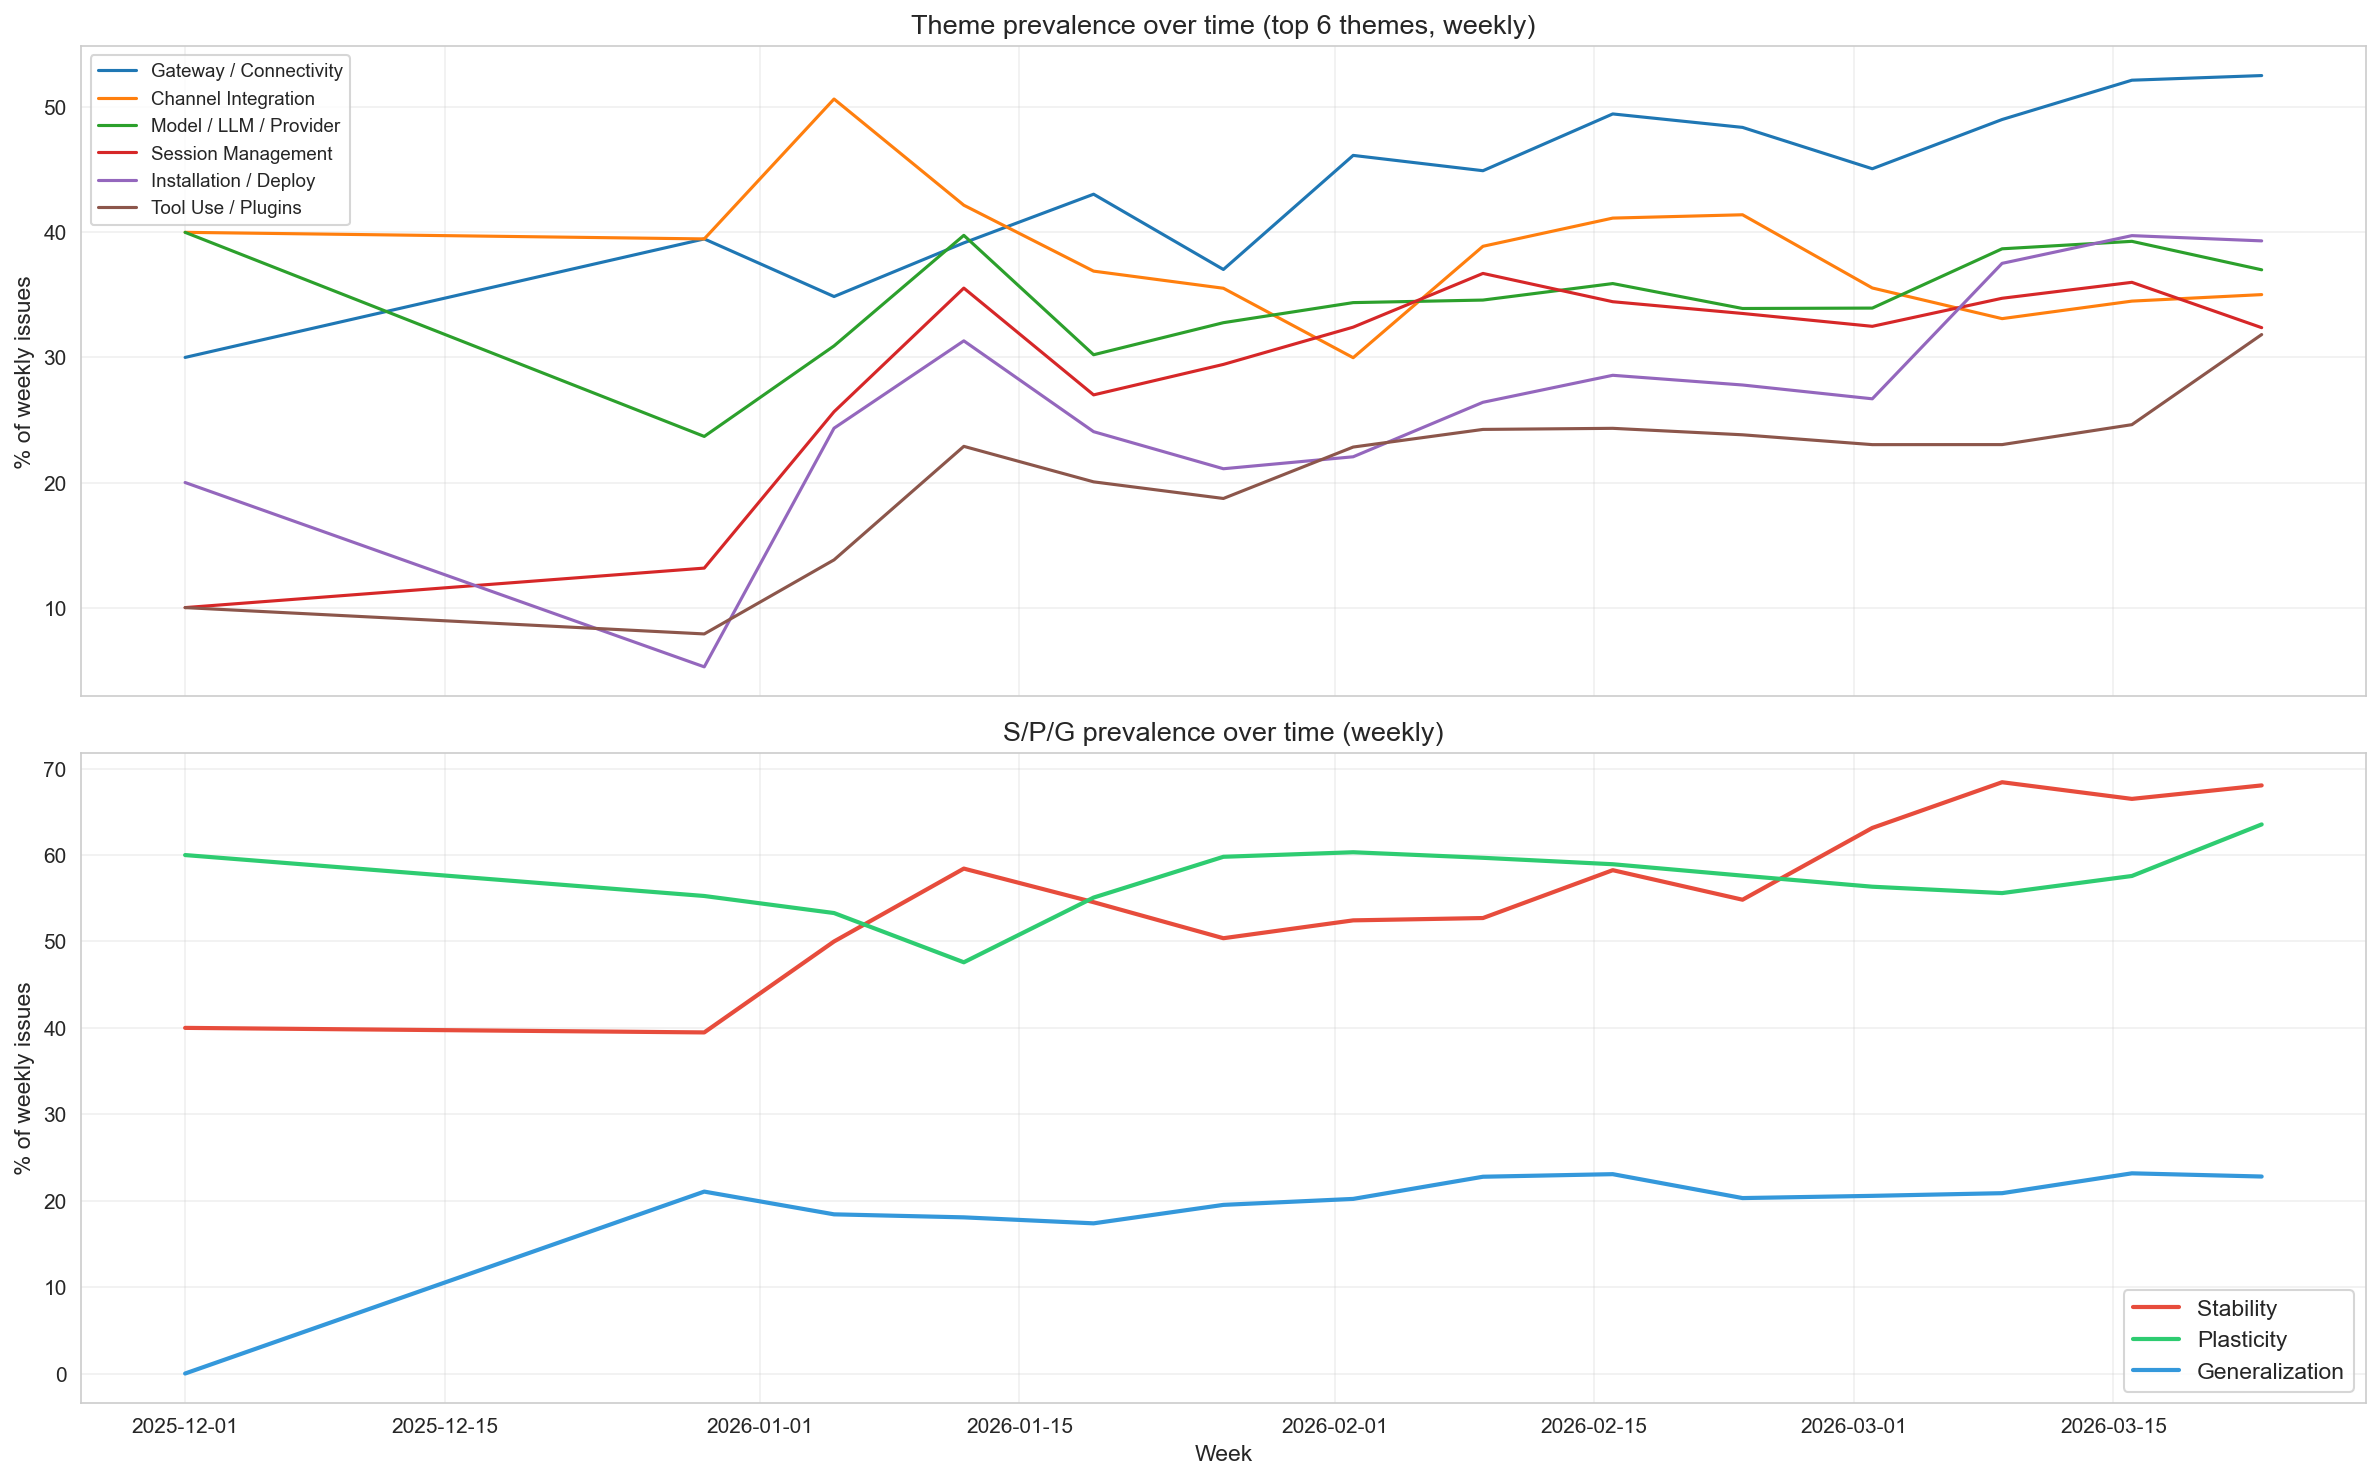

Saved figures/temporal_themes_spg.png


In [14]:
# ── Section 14: Temporal Evolution of Themes & S/P/G ─────────────────────

# Weekly theme proportions
df['week'] = df['created_at'].dt.to_period('W').apply(lambda p: p.start_time)
weekly_total = df.groupby('week').size()

# Theme proportions per week (top 6 themes only for readability)
top6 = [t[0] for t in theme_counter2.most_common(6)]

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# ── Top panel: Theme proportions over time ───────────────────────────────
for theme in top6:
    weekly_theme = df[df['themes_v2'].apply(lambda ts: theme in ts)].groupby('week').size()
    pct = (weekly_theme / weekly_total * 100).fillna(0)
    # Only plot weeks with >= 10 issues for stability
    mask = weekly_total >= 10
    axes[0].plot(pct.index[mask.values], pct.values[mask.values], label=theme, linewidth=1.5)

axes[0].set_ylabel("% of weekly issues")
axes[0].set_title("Theme prevalence over time (top 6 themes, weekly)")
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Bottom panel: S/P/G proportions over time ────────────────────────────
spg_colors = {'Stability': '#e74c3c', 'Plasticity': '#2ecc71', 'Generalization': '#3498db'}
for dim in ['Stability', 'Plasticity', 'Generalization']:
    weekly_dim = df[df['spg_scores'].apply(lambda d: dim in d)].groupby('week').size()
    pct = (weekly_dim / weekly_total * 100).fillna(0)
    mask = weekly_total >= 10
    axes[1].plot(pct.index[mask.values], pct.values[mask.values],
                 label=dim, color=spg_colors[dim], linewidth=2)

axes[1].set_ylabel("% of weekly issues")
axes[1].set_xlabel("Week")
axes[1].set_title("S/P/G prevalence over time (weekly)")
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/temporal_themes_spg.png", dpi=150)
plt.show()
print("Saved figures/temporal_themes_spg.png")

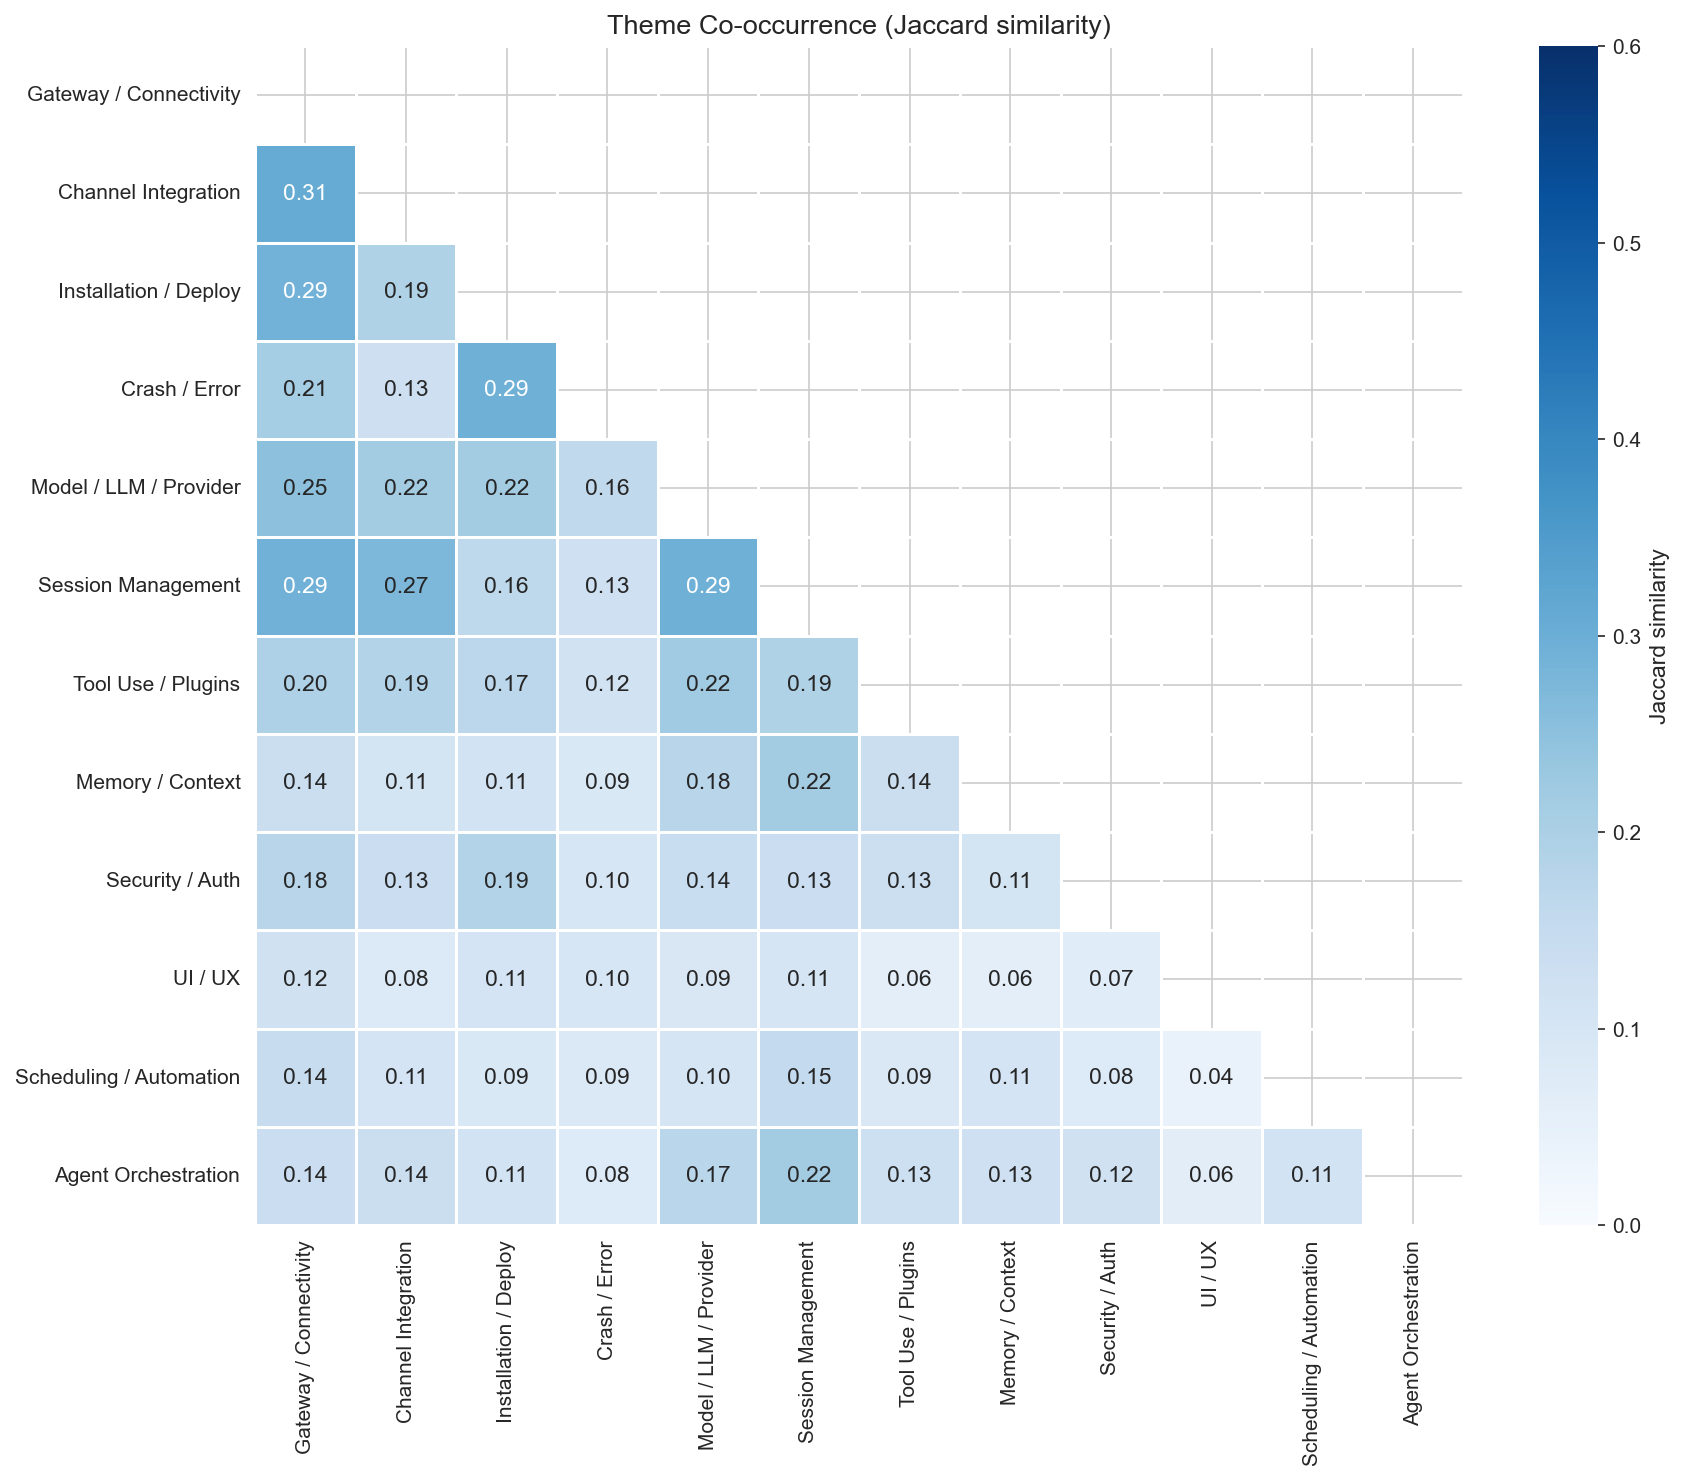

=== TOP 10 THEME CO-OCCURRENCE PAIRS (Jaccard) ===
  Gateway / Connectivity         × Channel Integration             co=4,409  J=0.307
  Model / LLM / Provider         × Session Management              co=3,538  J=0.294
  Installation / Deploy          × Crash / Error                   co=2,419  J=0.294
  Gateway / Connectivity         × Session Management              co=4,088  J=0.292
  Gateway / Connectivity         × Installation / Deploy           co=3,842  J=0.290
  Channel Integration            × Session Management              co=3,376  J=0.272
  Gateway / Connectivity         × Model / LLM / Provider          co=3,722  J=0.251
  Model / LLM / Provider         × Tool Use / Plugins              co=2,407  J=0.222
  Installation / Deploy          × Model / LLM / Provider          co=2,604  J=0.218
  Session Management             × Memory / Context                co=2,001  J=0.218

=== DESIGN TENSIONS (Stability vs Plasticity per theme) ===
Theme                                 

In [15]:
# ── Section 15: Theme Co-occurrence & Design Tensions ────────────────────

# Build co-occurrence matrix
theme_names = list(theme_counter2.keys())
n_themes = len(theme_names)
cooc = np.zeros((n_themes, n_themes), dtype=int)
for themes in df['themes_v2']:
    idxs = [theme_names.index(t) for t in themes if t in theme_names]
    for i in idxs:
        for j in idxs:
            cooc[i][j] += 1

cooc_df = pd.DataFrame(cooc, index=theme_names, columns=theme_names)

# Jaccard similarity for co-occurrence strength
jaccard = np.zeros((n_themes, n_themes))
for i in range(n_themes):
    for j in range(n_themes):
        union = cooc[i][i] + cooc[j][j] - cooc[i][j]
        jaccard[i][j] = cooc[i][j] / union if union > 0 else 0

jaccard_df = pd.DataFrame(jaccard, index=theme_names, columns=theme_names)

# Heatmap of Jaccard similarity
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(jaccard_df, dtype=bool))
sns.heatmap(jaccard_df, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            ax=ax, linewidths=0.5, vmin=0, vmax=0.6,
            cbar_kws={'label': 'Jaccard similarity'})
ax.set_title("Theme Co-occurrence (Jaccard similarity)")
plt.tight_layout()
plt.savefig("figures/theme_cooccurrence.png", dpi=150)
plt.show()

# Top co-occurring pairs
pairs = []
for i in range(n_themes):
    for j in range(i+1, n_themes):
        pairs.append({
            'Theme A': theme_names[i],
            'Theme B': theme_names[j],
            'Co-occur': cooc[i][j],
            'Jaccard': jaccard[i][j],
        })
pairs_df = pd.DataFrame(pairs).sort_values('Jaccard', ascending=False)

print("=== TOP 10 THEME CO-OCCURRENCE PAIRS (Jaccard) ===")
for _, row in pairs_df.head(10).iterrows():
    print(f"  {row['Theme A']:30s} × {row['Theme B']:30s}  "
          f"co={row['Co-occur']:>5,d}  J={row['Jaccard']:.3f}")

# ── Design Tensions (S-P conflicts per theme) ────────────────────────────
print("\n=== DESIGN TENSIONS (Stability vs Plasticity per theme) ===")
print(f"{'Theme':<35s} {'S%':>6s} {'P%':>6s} {'Gap':>6s} {'Tension':>10s}")
print("-" * 70)
tensions = []
for theme in theme_names:
    s_pct = cross_pct.loc['Stability', theme]
    p_pct = cross_pct.loc['Plasticity', theme]
    gap = s_pct - p_pct
    direction = "S >> P" if gap > 10 else ("P >> S" if gap < -10 else "balanced")
    tensions.append({'theme': theme, 's_pct': s_pct, 'p_pct': p_pct,
                     'gap': gap, 'direction': direction})
    print(f"  {theme:<33s} {s_pct:>5.1f}% {p_pct:>5.1f}% {gap:>+5.1f}%  {direction:>10s}")

print("\nSaved figures/theme_cooccurrence.png")

=== RESOLUTION METRICS PER THEME ===
Theme                                Total Closed   Rate  Med days Still open
--------------------------------------------------------------------------------
  Gateway / Connectivity            10,534  6,129 58.2%      3.2d      4,405
  Channel Integration                8,222  4,898 59.6%      3.2d      3,324
  Installation / Deploy              6,558  3,604 55.0%      3.0d      2,954
  Crash / Error                      4,100  1,795 43.8%      2.0d      2,305
  Model / LLM / Provider             8,002  4,529 56.6%      3.2d      3,473
  Session Management                 7,562  4,292 56.8%      3.5d      3,270
  Tool Use / Plugins                 5,264  2,970 56.4%      3.5d      2,294
  Memory / Context                   3,631  2,016 55.5%      3.7d      1,615
  Security / Auth                    4,058  2,362 58.2%      3.4d      1,696
  UI / UX                            2,384  1,335 56.0%      2.9d      1,049
  Scheduling / Automation         

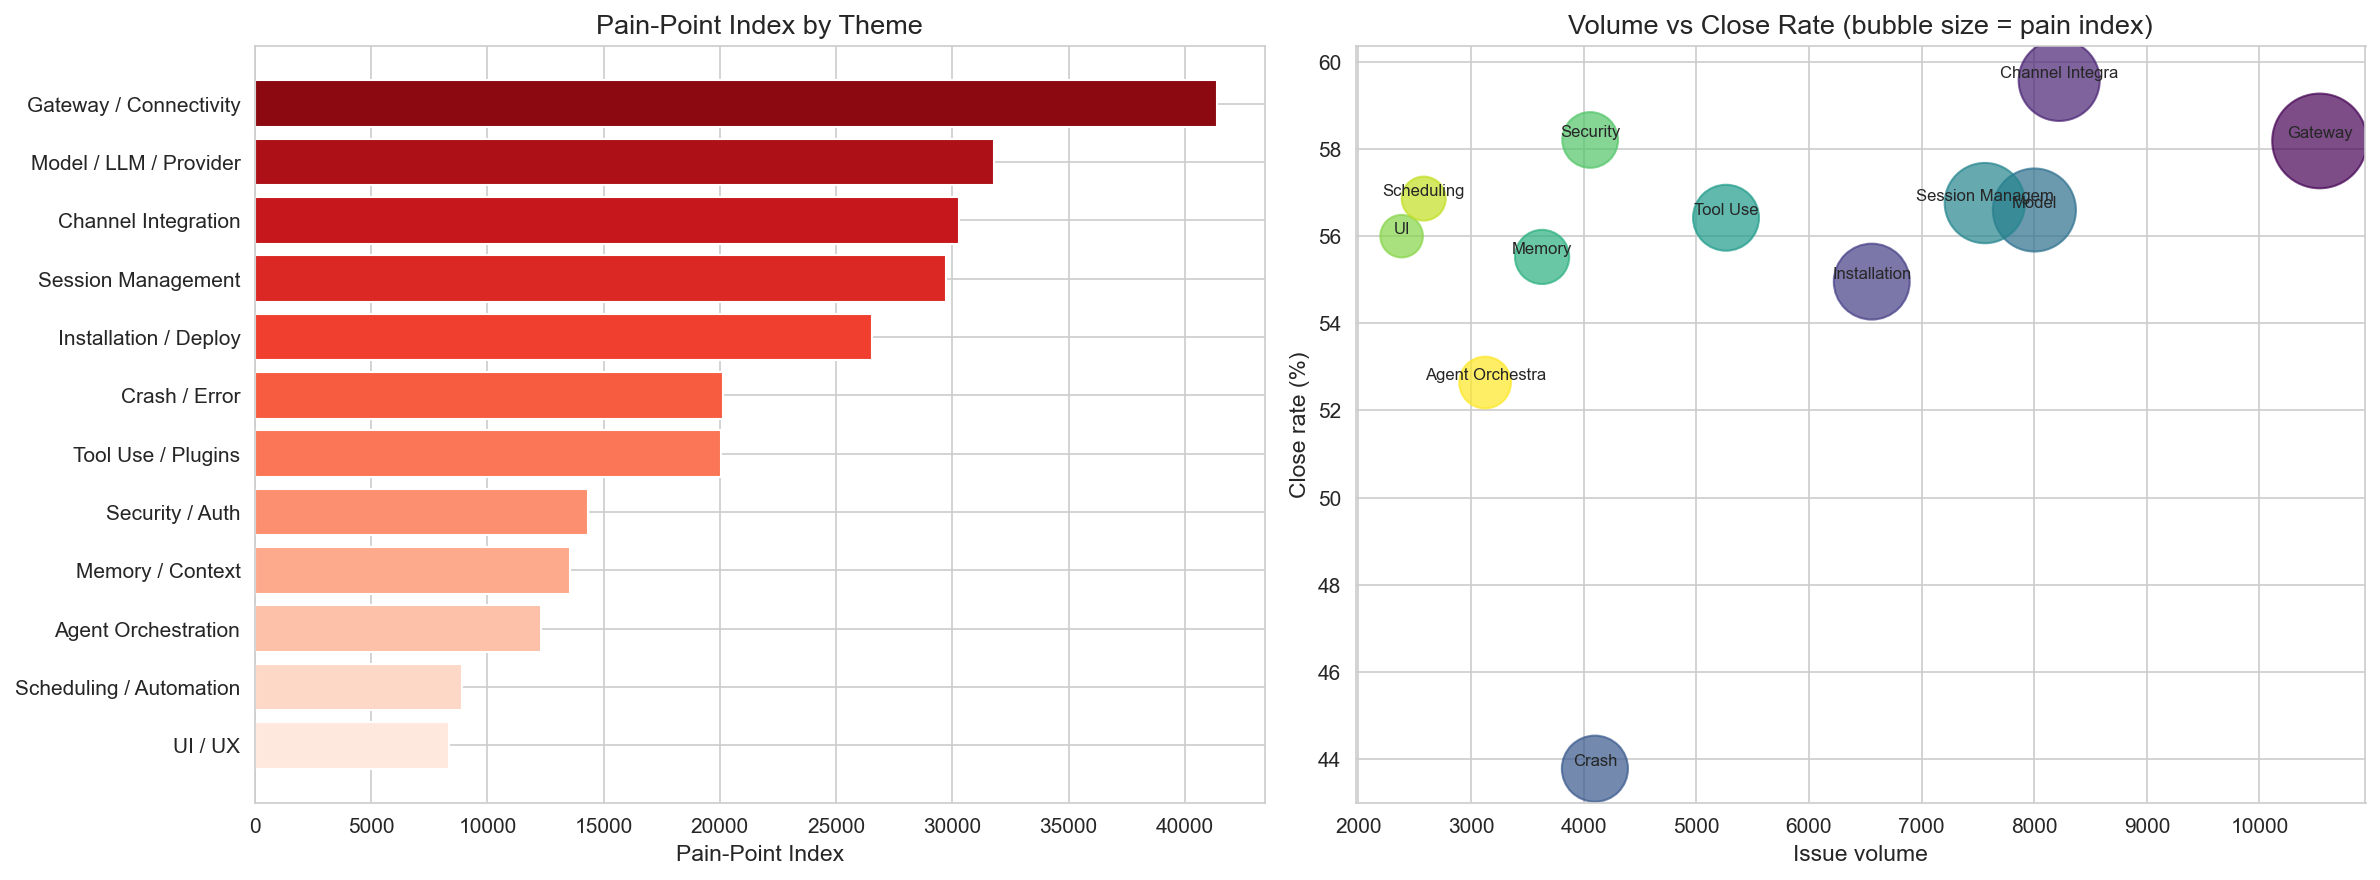

Saved figures/pain_point_index.png


In [16]:
# ── Section 16: Pain-Point Index & Resolution Analysis ───────────────────
# Pain-Point Index = volume × (1 - close_rate) × avg_open_days_if_still_open

# Resolution stats per theme
print("=== RESOLUTION METRICS PER THEME ===")
print(f"{'Theme':<35s} {'Total':>6s} {'Closed':>6s} {'Rate':>6s} {'Med days':>9s} {'Still open':>10s}")
print("-" * 80)

pain_data = []
for theme in theme_names:
    mask = df['themes_v2'].apply(lambda ts: theme in ts)
    sub = df[mask]
    total = len(sub)
    closed = (sub['state'] == 'closed').sum()
    rate = closed / total if total > 0 else 0
    # Median lifetime for closed issues
    closed_sub = sub[sub['state'] == 'closed']
    med_life = closed_sub['lifetime_days'].median() if len(closed_sub) > 0 else float('nan')
    still_open = (sub['state'] == 'open').sum()
    
    pain_data.append({
        'theme': theme, 'total': total, 'closed': closed,
        'rate': rate, 'med_life': med_life, 'still_open': still_open,
    })
    print(f"  {theme:<33s} {total:>6,d} {closed:>6,d} {rate:>5.1%} {med_life:>8.1f}d {still_open:>10,d}")

pain_df = pd.DataFrame(pain_data)

# Pain-point index: volume × open_fraction × (1 + log(still_open))
pain_df['open_frac'] = 1 - pain_df['rate']
pain_df['pain_index'] = pain_df['total'] * pain_df['open_frac'] * (1 + np.log1p(pain_df['still_open']))

print("\n=== PAIN-POINT INDEX (higher = more pain) ===")
pain_ranked = pain_df.sort_values('pain_index', ascending=False)
for _, row in pain_ranked.iterrows():
    print(f"  {row['theme']:<35s}  pain={row['pain_index']:>10,.0f}  "
          f"(vol={row['total']:>6,d}, open%={row['open_frac']:.1%}, still_open={row['still_open']:>5,d})")

# ── S/P/G resolution rates ───────────────────────────────────────────────
print("\n=== S/P/G RESOLUTION RATES ===")
for dim in ['Stability', 'Plasticity', 'Generalization', 'Unclassified']:
    mask = df['primary_spg'] == dim
    sub = df[mask]
    total = len(sub)
    closed = (sub['state'] == 'closed').sum()
    rate = closed / total if total > 0 else 0
    med_life = sub[sub['state'] == 'closed']['lifetime_days'].median() if closed > 0 else 0.0
    print(f"  {dim:<18s}  total={total:>6,d}  closed={closed:>6,d} ({rate:.1%})  "
          f"median lifetime={med_life:.1f}d")

# ── Visualization ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: pain index
axes[0].barh(range(len(pain_ranked)), pain_ranked['pain_index'].values,
             color=sns.color_palette("Reds_r", len(pain_ranked)))
axes[0].set_yticks(range(len(pain_ranked)))
axes[0].set_yticklabels(pain_ranked['theme'].values, fontsize=10)
axes[0].invert_yaxis()
axes[0].set_xlabel("Pain-Point Index")
axes[0].set_title("Pain-Point Index by Theme")

# Right: close rate vs volume scatter
axes[1].scatter(pain_df['total'], pain_df['rate'] * 100,
                s=pain_df['pain_index'] / 20, alpha=0.7,
                c=range(len(pain_df)), cmap='viridis')
for _, row in pain_df.iterrows():
    axes[1].annotate(row['theme'].split('/')[0].strip()[:15],
                     (row['total'], row['rate']*100),
                     fontsize=8, ha='center', va='bottom')
axes[1].set_xlabel("Issue volume")
axes[1].set_ylabel("Close rate (%)")
axes[1].set_title("Volume vs Close Rate (bubble size = pain index)")

plt.tight_layout()
plt.savefig("figures/pain_point_index.png", dpi=150)
plt.show()
print("Saved figures/pain_point_index.png")

In [ ]:
# ── Section 17: Export Classification Data ───────────────────────────────

# Theme table CSV
theme_export = []
for theme in theme_names:
    mask = df['themes_v2'].apply(lambda ts: theme in ts)
    sub = df[mask]
    theme_export.append({
        'theme': theme,
        'multi_label_count': len(sub),
        'multi_label_pct': len(sub) / len(df) * 100,
        'primary_count': (df['primary_theme'] == theme).sum(),
        'primary_pct': (df['primary_theme'] == theme).sum() / len(df) * 100,
        'close_rate': (sub['state'] == 'closed').mean() * 100,
        'median_lifetime_days': sub[sub['state'] == 'closed']['lifetime_days'].median(),
        'stability_pct': cross_pct.loc['Stability', theme],
        'plasticity_pct': cross_pct.loc['Plasticity', theme],
        'generalization_pct': cross_pct.loc['Generalization', theme],
        'sp_gap': cross_pct.loc['Stability', theme] - cross_pct.loc['Plasticity', theme],
    })
theme_table = pd.DataFrame(theme_export)
theme_table.to_csv('theme_table.csv', index=False)
print(f"Saved theme_table.csv ({len(theme_table)} rows)")

# S/P/G classification CSV
spg_export = df[['number', 'title', 'state', 'created_at', 'labels',
                  'primary_theme', 'primary_spg', 's_score', 'p_score', 'g_score']].copy()
spg_export['themes'] = df['themes_v2'].apply(lambda ts: '; '.join(ts))
spg_export.to_csv('spg_classification.csv', index=False)
print(f"Saved spg_classification.csv ({len(spg_export)} rows)")

# ── Representative Cases per Theme (top 3 highest-scoring per theme) ─────
print("\n=== REPRESENTATIVE CASES (top 3 per theme, highest score) ===\n")
rep_cases = []
for theme in theme_names:
    mask = df['themes_v2'].apply(lambda ts: theme in ts)
    sub = df[mask].copy()
    sub['_score'] = sub['theme_scores'].apply(lambda d: d.get(theme, 0))
    top3 = sub.nlargest(3, '_score')
    print(f"── {theme} ──")
    for _, row in top3.iterrows():
        title_short = str(row['title'])[:80]
        print(f"  #{row['number']}  (score={row['_score']})  {title_short}")
        rep_cases.append({
            'theme': theme, 'number': row['number'],
            'title': row['title'], 'score': row['_score'],
            'state': row['state'], 'primary_spg': row['primary_spg'],
        })
    print()

rep_df = pd.DataFrame(rep_cases)
rep_df.to_csv('representative_cases.csv', index=False)
print(f"Saved representative_cases.csv ({len(rep_df)} rows)")